In [2]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
import numpy as np
from keras.applications.resnet50 import preprocess_input

/Users/eric/miniforge3/envs/tf-vit/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50
IMAGES_PATH = "/Volumes/T9/HAM10000"
CSV_PATH = "/Volumes/T9/HAM10000_metadata.csv"
df = pd.read_csv("/Volumes/T9/HAM10000_metadata.csv")
# Définition des classes à conserver
CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'
}

In [4]:

# 📁 Mapping des chemins images dans une nouvelle colonne 'path'
df['path'] = df['image_id'].apply(lambda x: os.path.join(IMAGES_PATH, f"{x}.jpg"))

# 🏷️ Label to index mapping
label_to_index = {v: k for k, v in CLASS_LABELS.items()}
df = df[df['dx'].isin(CLASS_LABELS.values())]
df['label'] = df['dx'].map(label_to_index)


In [5]:
import os
import shutil
from sklearn.model_selection import train_test_split
import pandas as pd

# === 0. Paramètres ===
DATASET_DIR = '/Volumes/T9/HAM10000'  # répertoire contenant toutes les images originales
SAVE_DIR = '/Volumes/T9/HAM10000/data_split'  # répertoire cible pour sauvegarde
os.makedirs(SAVE_DIR, exist_ok=True)

# === 1. Split en 70% train, 15% val, 15% test ===
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42
)

# Conversion des labels en str (requis pour Keras et ImageDataGenerator)
for subset in [train_df, val_df, test_df]:
    subset['label'] = subset['label'].astype(str)



In [5]:
# === 2. Sauvegarde des DataFrames en CSV pour traçabilité future ===
train_df.to_csv(os.path.join(SAVE_DIR, 'train_labels.csv'), index=False)
val_df.to_csv(os.path.join(SAVE_DIR, 'val_labels.csv'), index=False)
test_df.to_csv(os.path.join(SAVE_DIR, 'test_labels.csv'), index=False)

# === 3. Copie physique des images ===
def save_images_from_df(df, subset_name):
    subset_dir = os.path.join(SAVE_DIR, subset_name)
    os.makedirs(subset_dir, exist_ok=True)
    
    for _, row in df.iterrows():
        image_filename = row['image_id']  # ou 'image' si c'est la colonne dans ton CSV
        possible_extensions = ['.jpg', '.jpeg', '.png']
        
        # Trouver le fichier existant avec une des extensions
        for ext in possible_extensions:
            test_path = os.path.join(DATASET_DIR, image_filename + ext)
            if os.path.exists(test_path):
                src_path = test_path
                break
        else:
            print(f"[⚠️] Image introuvable : {image_filename}")
            continue

        class_dir = os.path.join(subset_dir, row['label'])
        os.makedirs(class_dir, exist_ok=True)
        dst_path = os.path.join(class_dir, os.path.basename(src_path))
        shutil.copy2(src_path, dst_path)


save_images_from_df(train_df, 'train')
save_images_from_df(val_df, 'val')
save_images_from_df(test_df, 'test')


KeyboardInterrupt: 

In [6]:
# 🔁 Conversion des labels en string
train_df['label'] = train_df['label'].astype(str)
val_df['label'] = val_df['label'].astype(str)
test_df['label'] = test_df['label'].astype(str)


In [5]:
def print_class_distribution(df, name="Dataset"):
    print(f"\n📊 Répartition dans {name} :")
    dist = df['label'].value_counts().sort_index()
    for i, count in dist.items():
        print(f"{CLASS_LABELS[int(i)]:<6} : {count}")

print_class_distribution(train_df, "Train")
print_class_distribution(val_df, "Validation")
print_class_distribution(test_df, "Test")


📊 Répartition dans Train :
akiec  : 262
bcc    : 411
bkl    : 879
df     : 92
nv     : 5364
vasc   : 114
mel    : 890

📊 Répartition dans Validation :
akiec  : 33
bcc    : 51
bkl    : 110
df     : 12
nv     : 670
vasc   : 14
mel    : 111

📊 Répartition dans Test :
akiec  : 32
bcc    : 52
bkl    : 110
df     : 11
nv     : 671
vasc   : 14
mel    : 112


In [7]:
# Facteurs de sampling (uniquement pour train)
sampling_factors = {
    0: 14,    # akiec
    1: 1,     # bcc
    2: 4.2,   # bkl
    3: 1,    # df
    4: 0.8,  # nv
    5: 1,    # vasc
    6: 4.4    # mel
}

# Vérification des répartitions
def print_class_distribution(df, name="Dataset"):
    dist = df['label'].value_counts().sort_index()
    print(f"\n📊 Répartition des classes dans {name} :")
    for i, count in dist.items():
        class_name = CLASS_LABELS[int(i)]
        print(f"{class_name:<6} : {count}")

print_class_distribution(train_df, "Train")
print_class_distribution(val_df, "Validation")
print_class_distribution(test_df, "Test Interne")

def resample_dataframe(df, factors):
    resampled_df = []

    for label, factor in factors.items():
        subset = df[df['label'] == str(label)]
        n_samples = int(len(subset) * factor)

        if factor > 1:
            duplicated = pd.concat([subset] * int(factor), ignore_index=True)
            remainder = int((factor % 1) * len(subset))
            if remainder > 0:
                duplicated = pd.concat([duplicated, subset.sample(n=remainder, replace=True, random_state=42)], ignore_index=True)
        elif factor < 1:
            duplicated = subset.sample(n=n_samples, random_state=42)
        else:
            duplicated = subset

        resampled_df.append(duplicated)

    return pd.concat(resampled_df, ignore_index=True).sample(frac=1, random_state=42)

# ➕ Application du resampling uniquement sur le train
train_df_balanced = resample_dataframe(train_df, sampling_factors)

train_df_balanced['label'] = train_df_balanced['label'].astype(str)

# 🔍 Vérification finale
print_class_distribution(train_df_balanced, "Train (Resampled)")




📊 Répartition des classes dans Train :
akiec  : 262
bcc    : 411
bkl    : 879
df     : 92
nv     : 5364
vasc   : 114
mel    : 890

📊 Répartition des classes dans Validation :
akiec  : 33
bcc    : 51
bkl    : 110
df     : 12
nv     : 670
vasc   : 14
mel    : 111

📊 Répartition des classes dans Test Interne :
akiec  : 32
bcc    : 52
bkl    : 110
df     : 11
nv     : 671
vasc   : 14
mel    : 112

📊 Répartition des classes dans Train (Resampled) :
akiec  : 3668
bcc    : 411
bkl    : 3691
df     : 92
nv     : 4291
vasc   : 114
mel    : 3916


In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import Sequence

# Définition des classes rares (indices int)
RARE_CLASSES = [0, 2, 6]  # akiec, df, vasc, mel

# Séparation des dataframes en classes rares et communes
df_rare = train_df[train_df['label'].astype(int).isin(RARE_CLASSES)]
df_common = train_df[~train_df['label'].astype(int).isin(RARE_CLASSES)]

# Liste complète des classes en str (pour forcer la même encodage one-hot)
all_classes = sorted(train_df['label'].astype(str).unique())

# Augmentation douce pour classes communes
common_aug = ImageDataGenerator(
    rotation_range=35,
    zoom_range=[0.8, 1.2],
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    shear_range=0.05,
    vertical_flip=False,
    brightness_range=[0.8, 1.2],
    fill_mode='reflect',
    channel_shift_range=10.0,
    preprocessing_function=preprocess_input,
)

# Augmentation forte pour classes rares
rare_aug = ImageDataGenerator(
    rotation_range=60,                # rotations réalistes sans tout retourner
    zoom_range=[0.8, 1.2],                   # léger zoom in/out
    width_shift_range=0.15,          # petits déplacements
    height_shift_range=0.15,
    horizontal_flip=True,            # miroir ok
    vertical_flip=False,             # généralement pas réaliste en dermato
    shear_range=0.1,                  # légère déformation
    brightness_range=[0.80, 1.2],   # variations douces d’éclairage
    channel_shift_range=10.0,        # petit ajustement des couleurs
    fill_mode='reflect',
    preprocessing_function=preprocess_input,
)

# Générateurs pour classes communes et rares avec classes fixes
common_gen = common_aug.flow_from_dataframe(
    df_common,
    x_col='path',
    y_col='label',
    class_mode='categorical',
    classes=all_classes,
    target_size=(224, 224),
    batch_size=32,
    shuffle=True,
)

rare_gen = rare_aug.flow_from_dataframe(
    df_rare,
    x_col='path',
    y_col='label',
    class_mode='categorical',
    classes=all_classes,
    target_size=(224, 224),
    batch_size=32,
    shuffle=True,
)

# Générateur combiné avec batch_size constant
class CombinedGenerator(Sequence):
    def __init__(self, gen1, gen2, batch_size):
        self.gen1 = gen1
        self.gen2 = gen2
        self.batch_size = batch_size
        self.half_batch = batch_size // 2

    def __len__(self):
        return max(len(self.gen1), len(self.gen2))

    def __getitem__(self, index):
        x1, y1 = self.gen1[index % len(self.gen1)]
        x2, y2 = self.gen2[index % len(self.gen2)]

        # Sous-échantillonnage si batch trop grand
        if x1.shape[0] > self.half_batch:
            idx = tf.random.shuffle(tf.range(x1.shape[0]))[:self.half_batch]
            x1, y1 = tf.gather(x1, idx), tf.gather(y1, idx)

        if x2.shape[0] > self.half_batch:
            idx = tf.random.shuffle(tf.range(x2.shape[0]))[:self.half_batch]
            x2, y2 = tf.gather(x2, idx), tf.gather(y2, idx)

        x = tf.concat([x1, x2], axis=0)
        y = tf.concat([y1, y2], axis=0)
        return x, y

# Instanciation du générateur combiné
train_generator = CombinedGenerator(common_gen, rare_gen, batch_size=32)

# Accès au premier batch (correct pour Sequence)
images, labels = train_generator[0]

# Affichage min et max avec tf.reduce_min/max et numpy()
images_min = tf.reduce_min(images).numpy()
images_max = tf.reduce_max(images).numpy()

print(f"Nouvelle plage des pixels : {images_min} {images_max}")
print(f"Taille du batch images : {images.shape}, labels : {labels.shape}")


Found 5981 validated image filenames belonging to 7 classes.
Found 2031 validated image filenames belonging to 7 classes.
Nouvelle plage des pixels : -119.68000030517578 151.06100463867188
Taille du batch images : (32, 224, 224, 3), labels : (32, 7)


2025-07-06 22:24:11.045511: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-07-06 22:24:11.045539: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2025-07-06 22:24:11.045542: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
I0000 00:00:1751833451.045553 1002606 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1751833451.045568 1002606 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# --- 📸 Data Augmentation pour l'entraînement ---
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,                 
    rotation_range=35,
    zoom_range=[0.8, 1.2],
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    shear_range=0.1,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='reflect',
    channel_shift_range=15.0,

)

# --- 🔍 Pas d'augmentation pour validation / test ---
val_test_datagen = ImageDataGenerator(
   preprocessing_function=preprocess_input              
)

# --- 🔁 Train generator ---
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42,
    #sample_weight=sample_weights
)

# --- 🎯 Validation generator ---
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# --- 🧪 Test generator ---
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 8012 validated image filenames belonging to 7 classes.
Found 1001 validated image filenames belonging to 7 classes.
Found 1002 validated image filenames belonging to 7 classes.


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# --- 🔍 Pas d'augmentation pour validation / test ---
val_test_datagen = ImageDataGenerator(
   preprocessing_function=preprocess_input              
)

In [9]:
# --- 🎯 Validation generator ---
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# --- 🧪 Test generator ---
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1001 validated image filenames belonging to 7 classes.
Found 1002 validated image filenames belonging to 7 classes.


In [8]:
images, labels = next(train_generator)
print(f"Nouvelle plage des pixels : {images.min()} {images.max()}")

TypeError: 'CombinedGenerator' object is not an iterator

In [7]:
# Alpha Pondéré

import numpy as np
from collections import Counter
from tqdm import tqdm

class_counts = Counter()

# Assure-toi que train_generator is not infinite (no shuffle, no repeat)
for i in tqdm(range(len(train_generator))):
    _, y_batch = train_generator[i]
    labels = np.argmax(y_batch, axis=1)
    class_counts.update(labels)

# Affichage propre
print("\n==> Distribution par classe :")
for idx, count in class_counts.items():
    print(f"Classe {idx} ({CLASS_LABELS[idx]}): {count} images")

# Calcul alpha pondéré inversé
total = sum(class_counts.values())
alpha = [total / class_counts[i] for i in range(len(CLASS_LABELS))]
alpha = np.array(alpha)
alpha = alpha / np.sum(alpha)

print("\n==> Alpha pondéré (normalisé) :")
for idx, a in enumerate(alpha):
    print(f"{CLASS_LABELS[idx]} (classe {idx}) : {a:.4f}")


100%|██████████| 251/251 [00:56<00:00,  4.44it/s]


==> Distribution par classe :
Classe 4 (nv): 5364 images
Classe 2 (bkl): 879 images
Classe 6 (mel): 890 images
Classe 5 (vasc): 114 images
Classe 1 (bcc): 411 images
Classe 0 (akiec): 262 images
Classe 3 (df): 92 images

==> Alpha pondéré (normalisé) :
akiec (classe 0) : 0.1347
bcc (classe 1) : 0.0859
bkl (classe 2) : 0.0401
df (classe 3) : 0.3836
nv (classe 4) : 0.0066
vasc (classe 5) : 0.3095
mel (classe 6) : 0.0396


In [10]:
alpha = np.array([0.1347, 0.0859, 0.0401, 0.3836, 0.0066, 0.3095, 0.0396])
alpha[6] *= 1.2 
alpha[6] *= 1.2 
alpha[6] *= 1.5 

In [10]:
#Bosst Alpha en phase de Tuning si besoin
import numpy as np

# Alpha initial
alpha = np.array([0.1347, 0.0859, 0.0401, 0.3836, 0.0066, 0.3095, 0.0396])

# Coefficients de boost personnalisés
boost_factors = {
    0: 1.5,  # akiec
    1: 1.,  # bcc
    2: 1.5,  # bkl
    3: 1,  # df
    4: 1,  # nv
    5: 1,  # vasc
    6: 3   # mel
}

# Appliquer les boosts
alpha_boosted = alpha.copy()
for idx, factor in boost_factors.items():
    alpha_boosted[idx] *= factor

# (Optionnel) Re-normaliser
alpha_boosted /= alpha_boosted.sum()

print(alpha_boosted)

def focal_loss(alpha=alpha_boosted, gamma=2.0):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1. - 1e-7)

        # Proba prédite pour la classe correcte
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)

        # Alpha pour la vraie classe
        alpha_factor = tf.reduce_sum(alpha * y_true, axis=-1)

        # Focal loss components
        focal_weight = tf.pow(1. - p_t, gamma)
        ce = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)

        # Combine
        loss = alpha_factor * focal_weight * ce
        return tf.reduce_mean(loss)
    return loss



[0.17319561 0.07363278 0.05156009 0.32881879 0.00565747 0.26530087
 0.10183439]


In [12]:

def focal_loss(alpha=alpha_boosted, gamma=3.0):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1. - 1e-7)

        # Proba prédite pour la classe correcte
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)

        # Alpha pour la vraie classe
        alpha_factor = tf.reduce_sum(alpha * y_true, axis=-1)

        # Focal loss components
        focal_weight = tf.pow(1. - p_t, gamma)
        ce = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)

        # Combine
        loss = alpha_factor * focal_weight * ce
        return tf.reduce_mean(loss)
    return loss


In [11]:
import tensorflow as tf
from tensorflow.keras import backend as K

from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.metrics import Recall, Precision, AUC
from tensorflow.keras import mixed_precision


# ⚙️ Politique de précision mixte
mixed_precision.set_global_policy('mixed_float16')



In [19]:
def focal_loss(alpha=0.25, gamma=1):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1. - 1e-7)

        # Proba prédite pour la classe correcte
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)

        # Alpha pour la vraie classe
        alpha_factor = tf.reduce_sum(alpha * y_true, axis=-1)

        # Focal loss components
        focal_weight = tf.pow(1. - p_t, gamma)
        ce = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)

        # Combine
        loss = alpha_factor * focal_weight * ce
        return tf.reduce_mean(loss)
    return loss


In [9]:

import tensorflow as tf

def focal_loss(alpha=None, gamma=2.):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1. - 1e-7)

        if alpha is not None:
            alpha_tensor = tf.constant(alpha, dtype=tf.float32)
            alpha_factor = tf.reduce_sum(y_true * alpha_tensor, axis=-1)
        else:
            alpha_factor = tf.ones(tf.shape(y_true)[0], dtype=tf.float32)

        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)
        focal_factor = tf.pow(1. - p_t, gamma)
        ce = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)

        return tf.reduce_mean(alpha_factor * focal_factor * ce)

    return loss


In [47]:
alpha_boosted = np.array([0.23318888, 0.04955027, 0.04633712, 0.44272091, 0.00379664,
       0.17864177, 0.04576441])

In [92]:
alpha_boosted

array([0.21194374, 0.06755822, 0.06317731, 0.36218584, 0.01037584,
       0.09744063, 0.18731842])

In [12]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import numpy as np
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras import mixed_precision, layers 
from tensorflow.keras.activations import swish
from tensorflow.keras.regularizers import l2

# === 1. Politique Mixed Precision ===
mixed_precision.set_global_policy('mixed_float16')

# === 1. Paramètres ===

N_CLASSES = 7

# === 3. Construction du modèle ===

# --- Chargement du modèle de base pré-entraîné ---
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = False  # Gèle la base au départ

# --- Ajout de la tête de classification ---
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation=swish)(x)  # ou tf.keras.activations.swish
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

output = layers.Dense(
    N_CLASSES,
    activation='softmax',
    dtype='float32',

)(x)

model = Model(inputs=base_model.input, outputs=output, name='HAM10000_Resnet5_mel')

# === 4. Compilation ===
optimizer = AdamW(learning_rate=1e-3, weight_decay=1e-4)



2025-07-07 09:41:44.685161: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-07-07 09:41:44.685209: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2025-07-07 09:41:44.685215: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
I0000 00:00:1751874104.685259  103270 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1751874104.685329  103270 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [10]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

def get_class_weights(train_df, train_generator, use_emphasis=True):
    train_df['label'] = train_df['label'].astype(str)

    class_names = list(train_generator.class_indices.keys())
    label_to_index = train_generator.class_indices
    y_indices = train_df['label'].map(label_to_index).values

    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.arange(len(class_names)),
        y=y_indices
    )

    if use_emphasis:
        emphasis = {'mel': 1.5, 'akiec': 2.0, 'df': 1.5}
        for label, factor in emphasis.items():
            if label in label_to_index:
                idx = label_to_index[label]
                class_weights[idx] *= factor

    # ✅ C’est cette ligne qui corrige ton bug
    return {i: float(weight) for i, weight in enumerate(class_weights)}



In [15]:
class_weight = get_class_weights(train_df, train_generator, use_emphasis=True)


NameError: name 'get_class_weights' is not defined

In [14]:
class_weight_dict = {
    0: 0.74,
    1: 0.96,
    2: 1.39,
    3: 0.46,
    4: 3.81,
    5: 0.50,
    6: 1.40
}


In [11]:
class_weight = {
    0: 0.1347,  # akiec
    1: 0.0859,  # bcc
    2: 0.0401,  # bkl
    3: 0.3836,  # df
    4: 0.0066,  # nv
    5: 0.3095,  # vasc
    6: 0.0396   # mel
}


In [32]:
model.compile(
    optimizer=optimizer,
    #loss= 'categorical_crossentropy',  # Focal loss personnalisée
    #loss = focal_loss(alpha=0.25, gamma=2.),
    #loss=focal_loss(alpha=None, gamma=2.),
    loss=focal_loss(alpha=alpha_boosted, gamma=3.),
    metrics=[
        'accuracy',
        Recall(name='recall'),
        Precision(name='precision'),
        AUC(name='auc', multi_label=False), 
    ]
)

In [18]:
#phase 1 Class Weight

#Class Weight
import numpy as np
CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'  # <-- focus ici
}
from sklearn.utils import class_weight

# Labels entiers pour train
y_train_int = train_df["label"].astype(int)

# Calcul auto
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)

# Dictionnaire de poids par classe
class_weights = dict(enumerate(weights))


In [24]:


from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

CHECKPOINT_AUC = 'Protocole-S-Resnet50-akiec_bkl_mel_overSboosted4-valAUC.keras'
CHECKPOINT_ACC = 'Protocole-S-Resnet50-akiec_bkl_mel_overSboosted4-valACC.keras'

callbacks = [
    # Early stopping sur val_auc (objectif principal)
    EarlyStopping(
        monitor='val_auc',
        patience=20,
        restore_best_weights=True,
        verbose=1,
        mode='max',

    ),

    # Sauvegarde du meilleur modèle basé sur val_auc
    ModelCheckpoint(
        filepath=CHECKPOINT_AUC,
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    ),

    # Sauvegarde secondaire sur val_accuracy
    ModelCheckpoint(
        filepath=CHECKPOINT_ACC,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),

    # Réduction du learning rate sur stagnation du val_auc
    ReduceLROnPlateau(
        monitor='val_auc',
        factor=0.9,
        patience=3,
        min_lr=1e-6,
        min_delta=1e-4,
        mode='max',
        verbose=1
    ),
    #dynamic_weight_callback
]


In [20]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# 1. Encoder les labels en entiers
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['label'])

# 2. Vérifier les correspondances string ↔️ int
print("Mapping classes :")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{i}: {class_name}")

# 3. Calculer class_counts avec les labels encodés
NUM_CLASSES = len(label_encoder.classes_)
class_counts = np.bincount(train_df['label_encoded'].values, minlength=NUM_CLASSES)

# 4. Affichage
print("\n📊 Nombre d'exemples par classe :")
for i, count in enumerate(class_counts):
    print(f"  Classe {i} ({label_encoder.classes_[i]}) : {count}")

# 5. Calcul alpha
inv_sqrt_freq = 1 / np.sqrt(class_counts)
alpha = inv_sqrt_freq / np.sum(inv_sqrt_freq)

print("\n📈 Alpha modéré par classe (normalisé) :")
class_alpha = {}
for i, a in enumerate(alpha):
    print(f"  Classe {i} ({label_encoder.classes_[i]}) : {a:.4f}")
    class_alpha[i] = float(np.round(a, 6))

print("\n📦 Dictionnaire alpha prêt à l'emploi :")
print(class_alpha)



Mapping classes :
0: 0
1: 1
2: 2
3: 3
4: 4
5: 5
6: 6

📊 Nombre d'exemples par classe :
  Classe 0 (0) : 262
  Classe 1 (1) : 411
  Classe 2 (2) : 879
  Classe 3 (3) : 92
  Classe 4 (4) : 5364
  Classe 5 (5) : 114
  Classe 6 (6) : 890

📈 Alpha modéré par classe (normalisé) :
  Classe 0 (0) : 0.1584
  Classe 1 (1) : 0.1265
  Classe 2 (2) : 0.0865
  Classe 3 (3) : 0.2674
  Classe 4 (4) : 0.0350
  Classe 5 (5) : 0.2402
  Classe 6 (6) : 0.0860

📦 Dictionnaire alpha prêt à l'emploi :
{0: 0.158441, 1: 0.126502, 2: 0.086502, 3: 0.267377, 4: 0.035017, 5: 0.240196, 6: 0.085965}


In [34]:
alpha

array([0.15844107, 0.12650203, 0.08650157, 0.26737727, 0.0350166 ,
       0.24019612, 0.08596534])

In [ ]:
def focal_loss(alpha=0.25, gamma=2.0):
    alpha = tf.constant(alpha, dtype=tf.float32)

    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)

        # S'assurer que les dimensions sont correctes : (batch_size, num_classes)
        y_true = tf.reshape(y_true, (-1, tf.shape(y_pred)[-1]))
        y_pred = tf.reshape(y_pred, (-1, tf.shape(y_pred)[-1]))

        # calcul de la focal loss
        ce = -y_true * tf.math.log(y_pred)
        alpha_factor = y_true * alpha
        modulating_factor = tf.pow(1.0 - y_pred, gamma)
        loss = alpha_factor * modulating_factor * ce

        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))

    return loss


In [33]:
# 3. Continuer l'entraînement
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,
    initial_epoch=0,
    callbacks=callbacks,
    #class_weight=class_weight,
    verbose=1
)

Epoch 1/60
492/492 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9942 - auc: 1.0000 - loss: 2.2732e-05 - precision: 0.9947 - recall: 0.9935
Epoch 1: val_auc did not improve from 0.98034

Epoch 1: val_accuracy did not improve from 0.85714
492/492 ━━━━━━━━━━━━━━━━━━━━ 94s 178ms/step - accuracy: 0.9942 - auc: 1.0000 - loss: 2.2729e-05 - precision: 0.9947 - recall: 0.9935 - val_accuracy: 0.8501 - val_auc: 0.9796 - val_loss: 0.0264 - val_precision: 0.8564 - val_recall: 0.8402 - learning_rate: 3.9683e-04
Epoch 2/60
492/492 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9961 - auc: 1.0000 - loss: 2.2974e-05 - precision: 0.9965 - recall: 0.9958
Epoch 2: val_auc did not improve from 0.98034

Epoch 2: val_accuracy did not improve from 0.85714
492/492 ━━━━━━━━━━━━━━━━━━━━ 84s 171ms/step - accuracy: 0.9961 - auc: 1.0000 - loss: 2.2963e-05 - precision: 0.9965 - recall: 0.9958 - val_accuracy: 0.8482 - val_auc: 0.9784 - val_loss: 0.0273 - val_precision: 0.8603 - val_recall: 0.8432 - learning_rat

In [74]:
# Vérification du nombre de couches dégelées
num_trainable = sum([layer.trainable for layer in model.layers])
print(f"Nombre total de couches dégelées : {num_trainable}")

Nombre total de couches dégelées : 3


In [12]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Assure-toi que les labels sont bien en string partout
train_df['label'] = train_df['label'].astype(str)

# Liste des classes connues par le generator
class_names = np.array(list(train_generator.class_indices.keys()))  # Ex: ['0', '1', '2', ...]

# Calcul des poids équilibrés
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=class_names,
    y=train_df['label']
)

# Met l'accent sur certaines classes
# Exemple : classe '0' x6 et classe '6' x2
emphasis = {'0': 1.5, '2' : 1.5, '6': 2}
for i, label in enumerate(class_names):
    if label in emphasis:
        class_weights[i] *= emphasis[label]

# Mapping avec les bons indices du générateur
class_weight_dict = {
    train_generator.class_indices[label]: weight
    for label, weight in zip(class_names, class_weights)
}


AttributeError: 'CombinedGenerator' object has no attribute 'class_indices'

In [10]:
class_weight_dict

{0: np.float64(6.552889858233369),
 1: np.float64(2.7848453249913105),
 2: np.float64(1.3021290427433772),
 3: np.float64(24.88198757763975),
 4: np.float64(0.21338020666879728),
 5: np.float64(10.040100250626567),
 6: np.float64(1.9290529695024077)}

In [32]:
print(train_generator.class_indices)


{'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6}


In [10]:
def targeted_focal_loss(target_classes, gamma=2, alpha=0.25, label_smoothing=0.0):
    # alpha peut être float ou dict {class_idx: alpha_value}
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        ce = -y_true * tf.math.log(y_pred)
        
        focal = tf.pow(1 - y_pred, gamma) * ce
        
        mask = tf.zeros_like(y_true)
        for c in target_classes:
            mask = tf.tensor_scatter_nd_update(mask, [[0, c]], [1.0])
        
        if isinstance(alpha, dict):
            alpha_vec = tf.zeros_like(y_true)
            for c in target_classes:
                alpha_val = alpha.get(c, 0.25)
                alpha_vec = tf.tensor_scatter_nd_update(alpha_vec, [[0, c]], [alpha_val])
        else:
            alpha_vec = alpha * mask
        
        focal_masked = alpha_vec * focal * mask
        ce_masked = ce * (1 - mask)
        
        loss_per_sample = tf.reduce_sum(focal_masked + ce_masked, axis=1)
        return tf.reduce_mean(loss_per_sample)
    return loss


In [45]:
#Class Weight
import numpy as np
CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'  # <-- focus ici
}
from sklearn.utils import class_weight

# Labels entiers pour train
y_train_int = train_df["label"].astype(int)

# Calcul auto
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)

# Dictionnaire de poids par classe
class_weights = dict(enumerate(weights))


In [11]:
#Avec Label Smoothing et alpha ciblée

import tensorflow as tf

def targeted_focal_loss(target_classes, gamma=2, alpha=0.25, label_smoothing=0.1):
    """
    Focal loss appliquée uniquement sur target_classes avec alpha ciblé.
    Pour les autres classes, on applique juste la cross-entropy.
    
    Args:
        target_classes (list of int): indices des classes ciblées par focal loss.
        gamma (float): paramètre gamma de la focal loss.
        alpha (float or dict): pondération alpha, soit float global, soit dict {class_idx: alpha_val}.
        label_smoothing (float): taux de lissage des labels.
    """
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        
        num_classes = tf.cast(tf.shape(y_true)[1], tf.float32)
        # Appliquer label smoothing
        y_true_ls = y_true * (1.0 - label_smoothing) + (label_smoothing / num_classes)
        
        # Cross-entropy de base
        ce = -y_true_ls * tf.math.log(y_pred)
        
        # Focal modulation
        focal = tf.pow(1 - y_pred, gamma) * ce
        
        # Construire le masque des classes ciblées (shape [num_classes])
        target_mask_single = tf.reduce_sum(tf.one_hot(target_classes, depth=tf.shape(y_true)[1]), axis=0)
        target_mask = tf.expand_dims(target_mask_single, 0)  # shape [1, num_classes]
        target_mask = tf.tile(target_mask, [tf.shape(y_true)[0], 1])  # shape [batch_size, num_classes]
        
        # Construire alpha_vec (shape [num_classes])
        if isinstance(alpha, dict):
            alpha_vec_single = tf.zeros([tf.shape(y_true)[1]], dtype=tf.float32)
            for c in target_classes:
                alpha_val = alpha.get(c, 0.25)
                alpha_vec_single += tf.one_hot(c, tf.shape(y_true)[1]) * alpha_val
            # Si tu veux un alpha=1 pour classes non ciblées, décommente la ligne suivante :
            # alpha_vec_single += (1.0 - tf.cast(alpha_vec_single > 0, tf.float32))
            alpha_vec = tf.tile(tf.expand_dims(alpha_vec_single, 0), [tf.shape(y_true)[0], 1])
        else:
            alpha_vec = alpha * tf.cast(target_mask, tf.float32)
        
        # Calcul final : focal loss sur classes ciblées + cross-entropy simple sur autres classes
        focal_masked = alpha_vec * focal * tf.cast(target_mask, tf.float32)
        ce_masked = ce * (1.0 - tf.cast(target_mask, tf.float32))
        
        loss_per_sample = tf.reduce_sum(focal_masked + ce_masked, axis=1)
        return tf.reduce_mean(loss_per_sample)
    
    return loss


In [13]:
# Toutes les classes dans l'ordre
class_names = sorted(train_df['label'].unique().tolist())

In [ ]:
import tensorflow as tf
import numpy as np

# Toutes les classes dans l'ordre
class_names = sorted(train_df['label'].unique().tolist())

class TargetedAugmentDataset:
    def __init__(self, dataframe, img_size, class_names, batch_size=32, augment=True):
        self.df = dataframe.reset_index(drop=True)
        self.img_size = img_size
        self.class_names = list(class_names)
        self.batch_size = batch_size
        self.augment = augment
        self.strong_aug_classes = tf.constant(['mel', 'bkl', 'akiec'])

    def get_dataset(self):
        paths = self.df['path'].values
        labels = self.df['label'].values

        dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
        dataset = dataset.map(self.process_example, num_parallel_calls=tf.data.AUTOTUNE)
        dataset = dataset.batch(self.batch_size).prefetch(tf.data.AUTOTUNE)
        return dataset

    def process_example(self, path, label):
        img = self.load_image(path)
        one_hot = self.encode_label(label)

        if self.augment:
            img = tf.cond(
                tf.reduce_any(tf.equal(label, self.strong_aug_classes)),
                lambda: self.strong_augmentation(img),
                lambda: self.standard_augmentation(img)
            )

        img = tf.keras.applications.resnet50.preprocess_input(img)
        return img, one_hot

    def load_image(self, path):
        img_raw = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img_raw, channels=3)
        img = tf.image.resize(img, self.img_size)
        img = tf.cast(img, tf.float32)
        return img

    def encode_label(self, label):
        table = tf.lookup.StaticHashTable(
            tf.lookup.KeyValueTensorInitializer(
                keys=tf.constant(self.class_names),
                values=tf.constant(list(range(len(self.class_names))), dtype=tf.int32)
            ),
            default_value=-1
        )
        index = table.lookup(label)
        return tf.one_hot(index, depth=len(self.class_names))

    def strong_augmentation(self, img):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.rot90(img, k=tf.random.uniform([], 1, 4, dtype=tf.int32))
        img = tf.image.random_brightness(img, max_delta=0.3)
        img = tf.image.random_contrast(img, 0.7, 1.3)
        img = tf.image.random_saturation(img, 0.7, 1.3)

        if tf.random.uniform(()) > 0.5:
            crop_frac = tf.random.uniform((), 0.8, 1.0)
            new_size = tf.cast(crop_frac * tf.cast(self.img_size, tf.float32), tf.int32)
            img = tf.image.resize_with_crop_or_pad(img, new_size[0], new_size[1])
            img = tf.image.resize(img, self.img_size)

        if tf.random.uniform(()) > 0.5:
            mask_size = tf.cast(tf.random.uniform((), 0.1, 0.3) * tf.cast(self.img_size[0], tf.float32), tf.int32)
            img = self.apply_cutout(img, mask_size)

        return tf.clip_by_value(img, 0.0, 255.0)

    def standard_augmentation(self, img):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, max_delta=0.1)
        img = tf.image.random_contrast(img, 0.9, 1.1)
        return tf.clip_by_value(img, 0.0, 255.0)

    def apply_cutout(self, img, size):
        h, w = self.img_size
        cy = tf.random.uniform([], 0, h, dtype=tf.int32)
        cx = tf.random.uniform([], 0, w, dtype=tf.int32)

        y1 = tf.maximum(0, cy - size // 2)
        y2 = tf.minimum(h, cy + size // 2)
        x1 = tf.maximum(0, cx - size // 2)
        x2 = tf.minimum(w, cx + size // 2)

        cutout_mask = tf.ones_like(img)
        cutout_mask = tf.tensor_scatter_nd_update(
            cutout_mask,
            indices=tf.reshape(tf.stack(tf.meshgrid(tf.range(y1, y2), tf.range(x1, x2), indexing="ij"), axis=-1), (-1, 2)),
            updates=tf.zeros(((y2 - y1) * (x2 - x1), 3))
        )
        return img * cutout_mask


In [ ]:
train_ds = TargetedAugmentDataset(
    dataframe=train_df_balanced,
    img_size=(380, 380),
    class_names=class_names,
    batch_size=32,
    augment=True,
   # apply_mixup_cutmix=True  # ← tu actives ici
).get_dataset()

val_ds = TargetedAugmentDataset(
    dataframe=val_df,
    img_size=(380, 380),
    class_names=class_names,
    batch_size=32,
    augment=False
).get_dataset()


2025-07-07 20:55:42.819172: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-07-07 20:55:42.819221: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2025-07-07 20:55:42.819228: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
I0000 00:00:1751914542.819308 1057089 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1751914542.819390 1057089 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [18]:
#Class Weight

CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'  # <-- focus ici
}
from sklearn.utils import class_weight

# Labels entiers pour train
y_train_int = train_df["label"].astype(int)

# Calcul auto
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)

# Dictionnaire de poids par classe
class_weights = dict(enumerate(weights))

class_weights[0] *= 1.8
class_weights[2] *= 1.8
class_weights[6] *= 2.5


In [21]:
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Poids initiaux boostés
initial_weights = {
    0: 1.8,  # akiec
    1: 1.0,  # bcc
    2: 1.8,  # bkl
    3: 1.0,  # df
    4: 1.0,  # nv
    5: 1.0,  # vasc
    6: 2.5   # mel
}

# Poids finaux (équilibrés)
final_weights = {k: 1.0 for k in initial_weights}

# Callback personnalisé
class DynamicClassWeight(Callback):
    def __init__(self, initial_weights, final_weights, total_epochs):
        super().__init__()
        self.initial_weights = initial_weights
        self.final_weights = final_weights
        self.total_epochs = total_epochs
        self.current_weights = initial_weights.copy()

    def on_epoch_begin(self, epoch, logs=None):
        factor = epoch / self.total_epochs
        for key in self.current_weights:
            start = self.initial_weights[key]
            end = self.final_weights[key]
            self.current_weights[key] = start + (end - start) * factor

        print(f"\n[Epoch {epoch+1}] => Updated class_weights: {self.current_weights}")
        self.model.class_weight = self.current_weights  # Pour custom training loop (si applicable)

# Nombre d'epochs du run bis
EPOCHS = 60

# Ajout du callback dynamique
dynamic_weight_callback = DynamicClassWeight(
    initial_weights=initial_weights,
    final_weights=final_weights,
    total_epochs=EPOCHS
)




In [19]:
import tensorflow as tf

# Taux de départ très bas (pour stabiliser la dernière phase)
initial_lr = 1e-4

# Nombre d'étapes par epoch
steps_per_epoch = len(train_df)  # ou ton `train_ds`

# Redémarrage tous les 3 epochs (ex. si 80 epochs => 4-5 cycles)
first_decay_steps = 3 * steps_per_epoch

# Scheduler CosineDecayRestarts configuré pour un "polissage"
lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=initial_lr,
    first_decay_steps=first_decay_steps,
    t_mul=2.0,           # on double la durée entre cycles à chaque fois
    m_mul=1.0,           # on garde la même amplitude (pas trop d'atténuation)
    alpha=0.1            # le LR minimum = 10% du max (donc ~1e-6)
)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)


In [ ]:
from tensorflow import keras
from tensorflow.keras import backend as K
import tensorflow as tf
from tensorflow.keras import mixed_precision
from tensorflow.keras import layers, Model, Input, optimizers, regularizers
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.layers import Dropout
from tensorflow.keras.metrics import Recall, Precision, AUC


from tensorflow.keras import backend as K
import gc
import tensorflow as tf

# 1. Vider la session Keras
K.clear_session()

# 2. Forcer le garbage collector Python
gc.collect()

# 3. (Optionnel) Réinitialiser la graine pour reproductibilité
tf.random.set_seed(42)

mixed_precision.set_global_policy('mixed_float16')

optimizer = optimizers.AdamW(
    learning_rate=1.1381e-04,
    weight_decay=1e-4,  # Tu peux monter à 1e-3 si besoin
    clipnorm=1.0
)

import tensorflow as tf
from tensorflow import keras
# ... (vos autres imports : AdamW, metrics, focal_loss, etc.)

# --- 1. Charger votre modèle existant ---
model_path = 'Protocole-S-Resnet50-akiec_bkl_mel_overSboosted3-valAUC.keras'
model = keras.models.load_model(model_path, 
                                #custom_objects={'focal_loss_fixed': focal_loss()},
                                compile=False)

# --- 2. Dégeler  ---
#for layer in model.layers:
#    if hasattr(layer, 'name') and (
#        layer.name.startswith('conv5_block') 
#     or layer.name.startswith('conv4_block') 
#     or layer.name.startswith('conv3_block')
#     or layer.name.startswith('conv2_block')
#    ):
 #       layer.trainable = True
 #   else:
  #      layer.trainable = False

# --- 1. Unfreeze toutes les couches ---
#for layer in model.layers:
 #   layer.trainable = True

# --- 2. Gèle uniquement les BatchNorm (recommandé) ---
# --- Dégel progressif : conv5 + conv4, mais BN gelés sauf dans ces blocs ---
for layer in model.layers:
    if hasattr(layer, 'name') and (
        layer.name.startswith('conv5_block') or
        layer.name.startswith('conv4_block') or
        layer.name.startswith('conv3_block')
    ):
        # Dégeler tout dans ces blocs, y compris les BN
        layer.trainable = True
    elif isinstance(layer, tf.keras.layers.BatchNormalization):
        # Geler les BatchNorm ailleurs
        layer.trainable = False
    else:
        # Geler tout le reste
        layer.trainable = False







In [29]:
optimizer = optimizers.AdamW(
    learning_rate=1.1381e-04,
    weight_decay=1e-4,  # Tu peux monter à 1e-3 si besoin
    clipnorm=1.0
)

model.compile(
    optimizer = optimizer,
    #loss=targeted_focal_loss(target_classes=[0, 3, 6], gamma=1.5, alpha={0:0.4, 1:1, 2:1, 3:0.2, 4:1, 5:1, 6:0.4}, label_smoothing=0.05),
    loss = focal_loss(alpha=alpha_boosted, gamma=2.),
    #loss = 'categorical_crossentropy',
    metrics=[
        'accuracy',
        Recall(name='recall'),
        Precision(name='precision'),
        AUC(name='auc')
    ]
)

In [22]:
# Vérification du nombre de couches dégelées
num_trainable = sum([layer.trainable for layer in model.layers])
print(f"Nombre total de couches dégelées : {num_trainable}")

Nombre total de couches dégelées : 136


In [38]:
alpha_boosted

array([0.13555399, 0.05762973, 0.02690282, 0.51470934, 0.0044279 ,
       0.20764147, 0.05313475])

In [30]:
# 3. Continuer l'entraînement

#steps_per_epoch = len(train_df) // BATCH_SIZE
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=80,
    initial_epoch=0,
    callbacks=callbacks,
    #use_multiprocessing=True,
    #class_weight=class_weights,
    #steps_per_epoch=steps_per_epoch,
    #class_weight=initial_weights,
    verbose=1
)

Epoch 1/80
506/506 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.9553 - auc: 0.9983 - loss: 9.2621e-04 - precision: 0.9590 - recall: 0.9528
Epoch 1: val_auc did not improve from 0.97066

Epoch 1: val_accuracy did not improve from 0.81119
506/506 ━━━━━━━━━━━━━━━━━━━━ 274s 502ms/step - accuracy: 0.9553 - auc: 0.9983 - loss: 9.2683e-04 - precision: 0.9590 - recall: 0.9528 - val_accuracy: 0.6703 - val_auc: 0.9195 - val_loss: 0.0380 - val_precision: 0.6820 - val_recall: 0.6513 - learning_rate: 1.1381e-04
Epoch 2/80
506/506 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.9345 - auc: 0.9965 - loss: 0.0022 - precision: 0.9400 - recall: 0.9277
Epoch 2: val_auc did not improve from 0.97066

Epoch 2: val_accuracy did not improve from 0.81119
506/506 ━━━━━━━━━━━━━━━━━━━━ 248s 490ms/step - accuracy: 0.9346 - auc: 0.9965 - loss: 0.0022 - precision: 0.9400 - recall: 0.9277 - val_accuracy: 0.7912 - val_auc: 0.9603 - val_loss: 0.0413 - val_precision: 0.8081 - val_recall: 0.7782 - learning_rate: 1.1

In [17]:
# 3. Continuer l'entraînement

#steps_per_epoch = len(train_df) // BATCH_SIZE
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=80,
    initial_epoch=0,
    callbacks=callbacks,
    #use_multiprocessing=True,
    #class_weight=class_weights,
    #steps_per_epoch=steps_per_epoch,
    verbose=1
)

Epoch 1/80


2025-07-05 11:11:14.426801: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 713ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 9.0970e-05 - precision: 1.0000 - recall: 1.0000
Epoch 1: val_auc improved from -inf to 0.98381, saving model to Protocole-S-Resnet50-ph8-valAUC.keras

Epoch 1: val_accuracy improved from -inf to 0.92108, saving model to Protocole-S-Resnet50-ph8-valACC.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 209s 748ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 9.1011e-05 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9211 - val_auc: 0.9838 - val_loss: 0.0782 - val_precision: 0.9245 - val_recall: 0.9171 - learning_rate: 1.1381e-05
Epoch 2/80
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 709ms/step - accuracy: 0.9997 - auc: 1.0000 - loss: 1.8124e-04 - precision: 0.9997 - recall: 0.9997
Epoch 2: val_auc did not improve from 0.98381

Epoch 2: val_accuracy did not improve from 0.92108
251/251 ━━━━━━━━━━━━━━━━━━━━ 182s 723ms/step - accuracy: 0.9997 - auc: 1.0000 - loss: 1.8137e-04 - precision: 0.9997 - recall: 0.9997 - val_accuracy: 

In [31]:
# 3. Continuer l'entraînement

#steps_per_epoch = len(train_df) // BATCH_SIZE
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=80,
    initial_epoch=0,
    callbacks=callbacks,
    #use_multiprocessing=True,
    #class_weight=class_weights,
    #steps_per_epoch=steps_per_epoch,
    verbose=1
)

Epoch 1/80
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.9457 - auc: 0.9975 - loss: 0.1454 - precision: 0.9493 - recall: 0.9429
Epoch 1: val_auc improved from 0.96323 to 0.97320, saving model to Protocole-S-Resnet50-akiec_bkl_mel_classweight1-valAUC.keras

Epoch 1: val_accuracy improved from 0.82018 to 0.83716, saving model to Protocole-S-Resnet50-akiec_bkl_mel_classweight1-valACC.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 37s 136ms/step - accuracy: 0.9457 - auc: 0.9975 - loss: 0.1453 - precision: 0.9493 - recall: 0.9430 - val_accuracy: 0.8372 - val_auc: 0.9732 - val_loss: 0.5916 - val_precision: 0.8437 - val_recall: 0.8302 - learning_rate: 2.3432e-04
Epoch 2/80
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.9572 - auc: 0.9986 - loss: 0.1059 - precision: 0.9595 - recall: 0.9557
Epoch 2: val_auc did not improve from 0.97320

Epoch 2: val_accuracy did not improve from 0.83716
251/251 ━━━━━━━━━━━━━━━━━━━━ 33s 131ms/step - accuracy: 0.9572 - auc: 0.9986 - loss: 0.1059 - precis

In [14]:
for i in range(5):
    x, y = train_gen[i]
    print(f"[OK] Batch {i} - x shape: {x.shape} - y shape: {y.shape}")


[OK] Batch 0 - x shape: (32, 299, 299, 3) - y shape: (32, 7)
[OK] Batch 1 - x shape: (32, 299, 299, 3) - y shape: (32, 7)
[OK] Batch 2 - x shape: (32, 299, 299, 3) - y shape: (32, 7)
[OK] Batch 3 - x shape: (32, 299, 299, 3) - y shape: (32, 7)
[OK] Batch 4 - x shape: (32, 299, 299, 3) - y shape: (32, 7)


In [ ]:
# Création des datasets depuis la classe TargetedAugmentDataset
train_ds = TargetedAugmentDataset(train_df, img_size=IMG_SIZE, batch_size=BATCH_SIZE, class_names=class_names, augment=True).get_dataset()
val_ds = TargetedAugmentDataset(val_df, img_size=IMG_SIZE, batch_size=BATCH_SIZE, class_names=class_names, augment=False).get_dataset()


steps_per_epoch = int(np.ceil(len(train_df) / BATCH_SIZE))
val_steps = int(np.ceil(len(val_df) / BATCH_SIZE))

# Préparation du fit avec tf.data.Dataset
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    initial_epoch=0,
    callbacks=callbacks,
    steps_per_epoch=steps_per_epoch,
    validation_steps=val_steps,
    verbose=1
)

In [2]:
import tensorflow as tf
print(tf.keras.__version__)


3.9.2


In [ ]:
#Class Weight

CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'  # <-- focus ici
}
from sklearn.utils import class_weight

# Labels entiers pour train
y_train_int = train_df["label"].astype(int)

# Calcul auto
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)

# Dictionnaire de poids par classe
class_weights = dict(enumerate(weights))

class_weights[0] *= 3
class_weights[6] *= 3


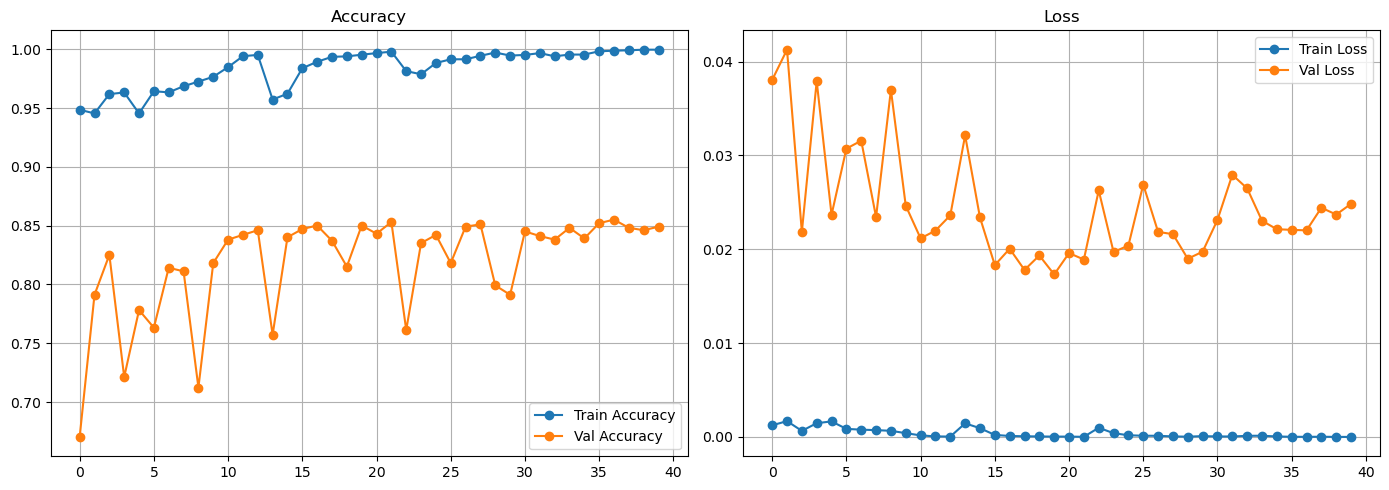

In [31]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    # 🔹 Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Val Accuracy', marker='o')
    plt.title('Accuracy')
    plt.legend()
    plt.grid(True)

    # 🔹 Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Val Loss', marker='o')
    plt.title('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# ✅ Appel de la fonction après le fit
plot_training_history(history)

Chargement des images du jeu de test...
Prédiction du modèle...
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 154ms/step
Génération de la matrice de confusion...


/var/folders/jj/3s72m7nx3039djzxqt_p86w80000gn/T/ipykernel_4072/3833457878.py:58: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/eric/miniforge3/envs/tf-vit/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


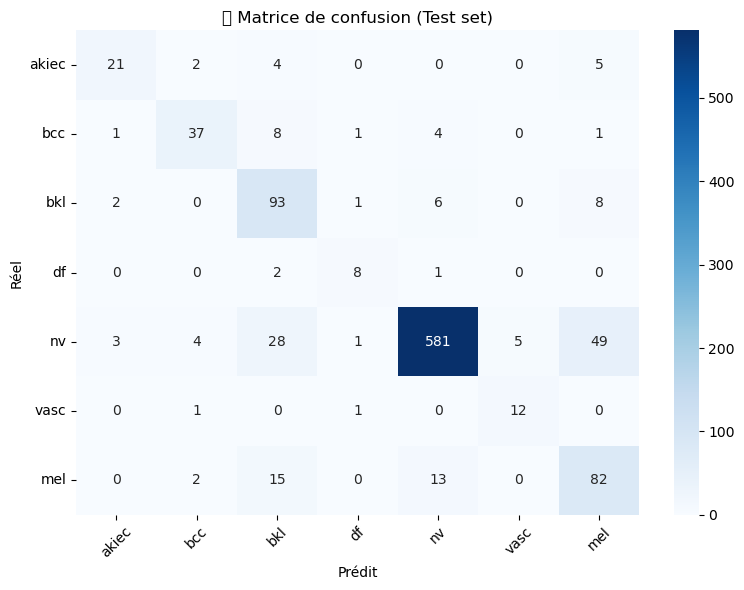


📄 Rapport de classification :

              precision    recall  f1-score   support

       akiec       0.78      0.66      0.71        32
         bcc       0.80      0.71      0.76        52
         bkl       0.62      0.85      0.72       110
          df       0.67      0.73      0.70        11
          nv       0.96      0.87      0.91       671
        vasc       0.71      0.86      0.77        14
         mel       0.57      0.73      0.64       112

    accuracy                           0.83      1002
   macro avg       0.73      0.77      0.74      1002
weighted avg       0.86      0.83      0.84      1002



In [32]:
#class Weight + Focal Loss 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import load_img, img_to_array
#from tensorflow.keras.applications.xception import preprocess_input

# === 🏷️ Labels et descriptions ===
CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'
}

# 📐 Taille des images attendue par le modèle (à adapter si besoin)
IMG_SIZE = (224, 224)


# 🧼 Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array  # Retourne un batch de 1


# 📥 Chargement des images de test
print("Chargement des images du jeu de test...")
X_test = np.array([preprocess_image(p) for p in test_df['path']])
y_test = test_df['label'].values

y_test = y_test.astype(int)

# 🤖 Prédictions
print("Prédiction du modèle...")
y_pred_proba = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)

# 📊 Matrice de confusion
print("Génération de la matrice de confusion...")
cm = confusion_matrix(y_test, y_pred)
labels = list(CLASS_LABELS.values())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('📉 Matrice de confusion (Test set)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 🧾 Rapport classification (precision, recall, F1-score)
print("\n📄 Rapport de classification :\n")
print(classification_report(y_test, y_pred, target_names=labels))



Chargement des images du jeu de test...
Prédiction du modèle...
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step
Génération de la matrice de confusion...


/var/folders/jj/3s72m7nx3039djzxqt_p86w80000gn/T/ipykernel_3237/3833457878.py:58: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/eric/miniforge3/envs/tf-vit/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


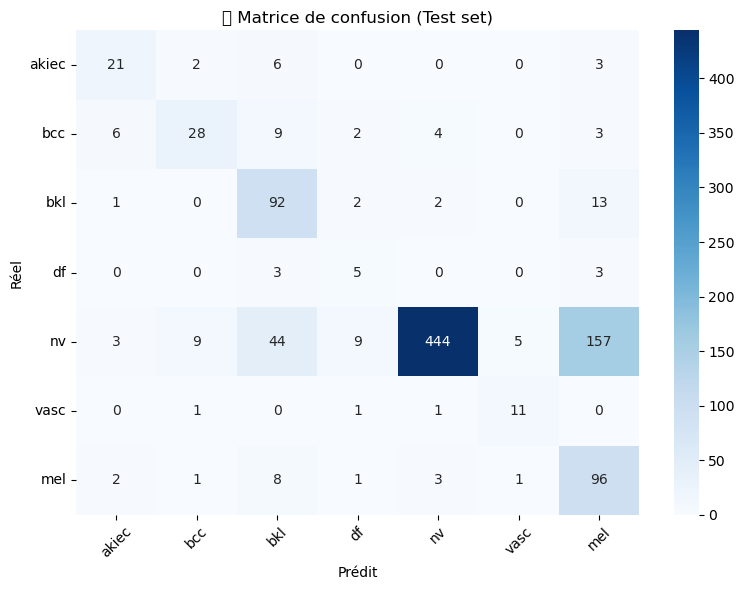


📄 Rapport de classification :

              precision    recall  f1-score   support

       akiec       0.64      0.66      0.65        32
         bcc       0.68      0.54      0.60        52
         bkl       0.57      0.84      0.68       110
          df       0.25      0.45      0.32        11
          nv       0.98      0.66      0.79       671
        vasc       0.65      0.79      0.71        14
         mel       0.35      0.86      0.50       112

    accuracy                           0.70      1002
   macro avg       0.59      0.68      0.61      1002
weighted avg       0.82      0.70      0.72      1002



In [17]:
#class Weight + Focal Loss 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import load_img, img_to_array
#from tensorflow.keras.applications.xception import preprocess_input

# === 🏷️ Labels et descriptions ===
CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'
}

# 📐 Taille des images attendue par le modèle (à adapter si besoin)
IMG_SIZE = (224, 224)


# 🧼 Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array  # Retourne un batch de 1


# 📥 Chargement des images de test
print("Chargement des images du jeu de test...")
X_test = np.array([preprocess_image(p) for p in test_df['path']])
y_test = test_df['label'].values

y_test = y_test.astype(int)

# 🤖 Prédictions
print("Prédiction du modèle...")
y_pred_proba = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)

# 📊 Matrice de confusion
print("Génération de la matrice de confusion...")
cm = confusion_matrix(y_test, y_pred)
labels = list(CLASS_LABELS.values())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('📉 Matrice de confusion (Test set)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 🧾 Rapport classification (precision, recall, F1-score)
print("\n📄 Rapport de classification :\n")
print(classification_report(y_test, y_pred, target_names=labels))



Chargement des images du jeu de test...
Prédiction du modèle...
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 148ms/step
Génération de la matrice de confusion...


/var/folders/jj/3s72m7nx3039djzxqt_p86w80000gn/T/ipykernel_2764/3833457878.py:58: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/eric/miniforge3/envs/tf-vit/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


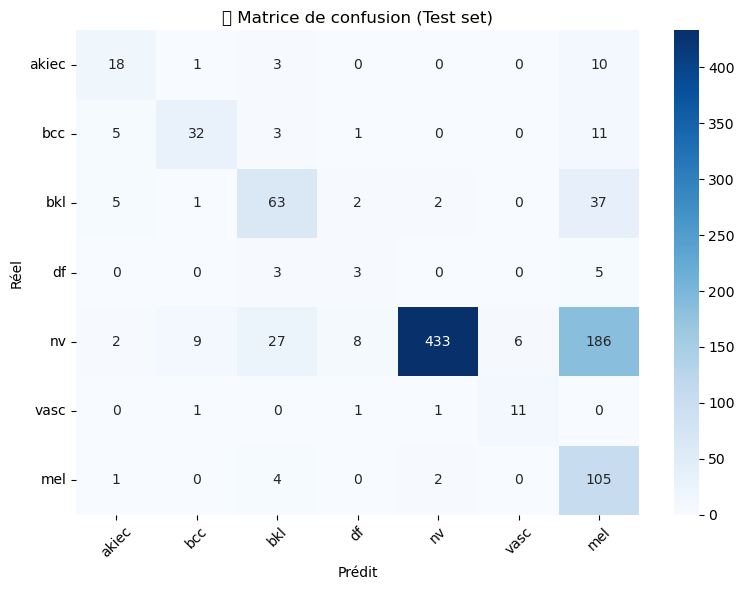


📄 Rapport de classification :

              precision    recall  f1-score   support

       akiec       0.58      0.56      0.57        32
         bcc       0.73      0.62      0.67        52
         bkl       0.61      0.57      0.59       110
          df       0.20      0.27      0.23        11
          nv       0.99      0.65      0.78       671
        vasc       0.65      0.79      0.71        14
         mel       0.30      0.94      0.45       112

    accuracy                           0.66      1002
   macro avg       0.58      0.63      0.57      1002
weighted avg       0.83      0.66      0.70      1002



In [27]:
#class Weight + Focal Loss 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import load_img, img_to_array
#from tensorflow.keras.applications.xception import preprocess_input

# === 🏷️ Labels et descriptions ===
CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'
}

# 📐 Taille des images attendue par le modèle (à adapter si besoin)
IMG_SIZE = (224, 224)


# 🧼 Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array  # Retourne un batch de 1


# 📥 Chargement des images de test
print("Chargement des images du jeu de test...")
X_test = np.array([preprocess_image(p) for p in test_df['path']])
y_test = test_df['label'].values

y_test = y_test.astype(int)

# 🤖 Prédictions
print("Prédiction du modèle...")
y_pred_proba = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)

# 📊 Matrice de confusion
print("Génération de la matrice de confusion...")
cm = confusion_matrix(y_test, y_pred)
labels = list(CLASS_LABELS.values())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('📉 Matrice de confusion (Test set)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 🧾 Rapport classification (precision, recall, F1-score)
print("\n📄 Rapport de classification :\n")
print(classification_report(y_test, y_pred, target_names=labels))



Chargement des images du jeu de test...
Prédiction du modèle...
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 160ms/step
Génération de la matrice de confusion...


/var/folders/jj/3s72m7nx3039djzxqt_p86w80000gn/T/ipykernel_1706/3833457878.py:58: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/eric/miniforge3/envs/tf-vit/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


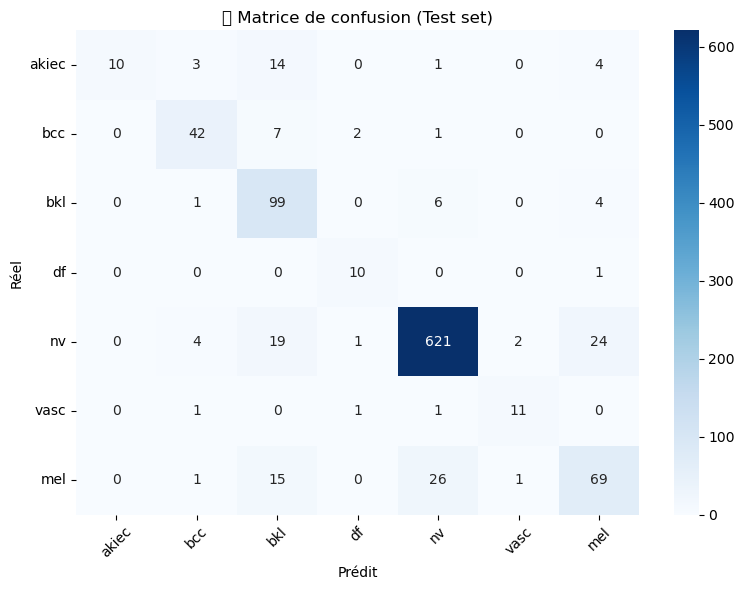


📄 Rapport de classification :

              precision    recall  f1-score   support

       akiec       1.00      0.31      0.48        32
         bcc       0.81      0.81      0.81        52
         bkl       0.64      0.90      0.75       110
          df       0.71      0.91      0.80        11
          nv       0.95      0.93      0.94       671
        vasc       0.79      0.79      0.79        14
         mel       0.68      0.62      0.64       112

    accuracy                           0.86      1002
   macro avg       0.80      0.75      0.74      1002
weighted avg       0.87      0.86      0.86      1002



In [52]:
#class Weight + Focal Loss 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import load_img, img_to_array
#from tensorflow.keras.applications.xception import preprocess_input

# === 🏷️ Labels et descriptions ===
CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'
}

# 📐 Taille des images attendue par le modèle (à adapter si besoin)
IMG_SIZE = (224, 224)


# 🧼 Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array  # Retourne un batch de 1


# 📥 Chargement des images de test
print("Chargement des images du jeu de test...")
X_test = np.array([preprocess_image(p) for p in test_df['path']])
y_test = test_df['label'].values

y_test = y_test.astype(int)

# 🤖 Prédictions
print("Prédiction du modèle...")
y_pred_proba = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)

# 📊 Matrice de confusion
print("Génération de la matrice de confusion...")
cm = confusion_matrix(y_test, y_pred)
labels = list(CLASS_LABELS.values())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('📉 Matrice de confusion (Test set)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 🧾 Rapport classification (precision, recall, F1-score)
print("\n📄 Rapport de classification :\n")
print(classification_report(y_test, y_pred, target_names=labels))



Chargement des images du jeu de test...
Prédiction du modèle...
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step
Génération de la matrice de confusion...


/var/folders/jj/3s72m7nx3039djzxqt_p86w80000gn/T/ipykernel_1079/3833457878.py:58: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/eric/miniforge3/envs/tf-vit/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


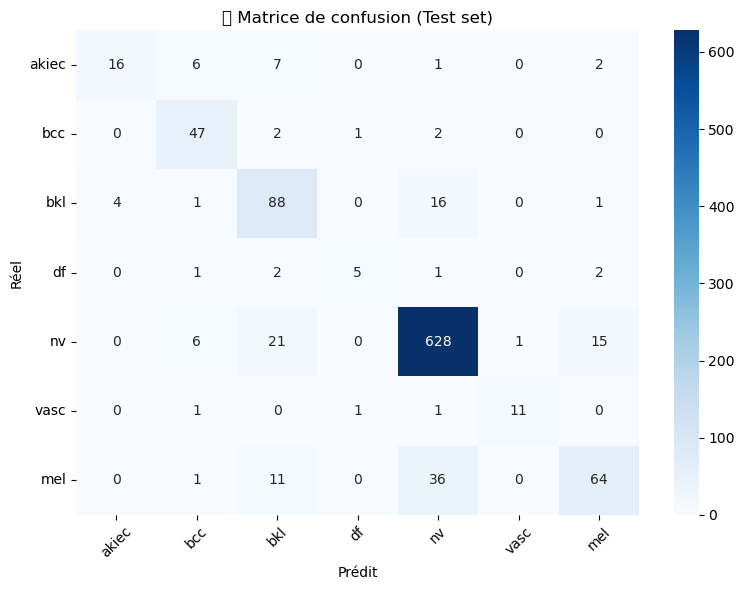


📄 Rapport de classification :

              precision    recall  f1-score   support

       akiec       0.80      0.50      0.62        32
         bcc       0.75      0.90      0.82        52
         bkl       0.67      0.80      0.73       110
          df       0.71      0.45      0.56        11
          nv       0.92      0.94      0.93       671
        vasc       0.92      0.79      0.85        14
         mel       0.76      0.57      0.65       112

    accuracy                           0.86      1002
   macro avg       0.79      0.71      0.73      1002
weighted avg       0.86      0.86      0.85      1002



In [23]:
#class Weight + Focal Loss 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import load_img, img_to_array
#from tensorflow.keras.applications.xception import preprocess_input

# === 🏷️ Labels et descriptions ===
CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'
}

# 📐 Taille des images attendue par le modèle (à adapter si besoin)
IMG_SIZE = (224, 224)


# 🧼 Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array  # Retourne un batch de 1


# 📥 Chargement des images de test
print("Chargement des images du jeu de test...")
X_test = np.array([preprocess_image(p) for p in test_df['path']])
y_test = test_df['label'].values

y_test = y_test.astype(int)

# 🤖 Prédictions
print("Prédiction du modèle...")
y_pred_proba = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)

# 📊 Matrice de confusion
print("Génération de la matrice de confusion...")
cm = confusion_matrix(y_test, y_pred)
labels = list(CLASS_LABELS.values())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('📉 Matrice de confusion (Test set)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 🧾 Rapport classification (precision, recall, F1-score)
print("\n📄 Rapport de classification :\n")
print(classification_report(y_test, y_pred, target_names=labels))



Chargement des images du jeu de test...
Prédiction du modèle...
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 147ms/step
Génération de la matrice de confusion...


/var/folders/jj/3s72m7nx3039djzxqt_p86w80000gn/T/ipykernel_1756/3833457878.py:58: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/eric/miniforge3/envs/tf-vit/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


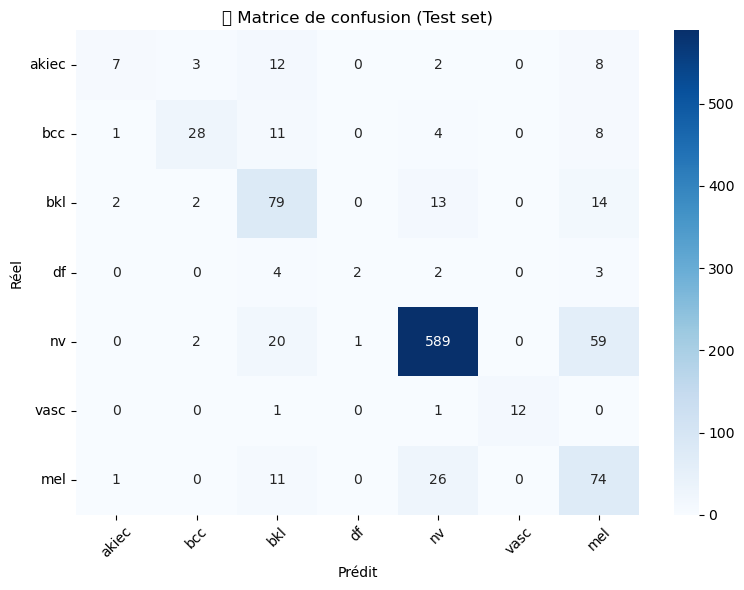


📄 Rapport de classification :

              precision    recall  f1-score   support

       akiec       0.64      0.22      0.33        32
         bcc       0.80      0.54      0.64        52
         bkl       0.57      0.72      0.64       110
          df       0.67      0.18      0.29        11
          nv       0.92      0.88      0.90       671
        vasc       1.00      0.86      0.92        14
         mel       0.45      0.66      0.53       112

    accuracy                           0.79      1002
   macro avg       0.72      0.58      0.61      1002
weighted avg       0.82      0.79      0.79      1002



In [28]:
#class Weight + Focal Loss 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import load_img, img_to_array
#from tensorflow.keras.applications.xception import preprocess_input

# === 🏷️ Labels et descriptions ===
CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'
}

# 📐 Taille des images attendue par le modèle (à adapter si besoin)
IMG_SIZE = (224, 224)


# 🧼 Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array  # Retourne un batch de 1


# 📥 Chargement des images de test
print("Chargement des images du jeu de test...")
X_test = np.array([preprocess_image(p) for p in test_df['path']])
y_test = test_df['label'].values

y_test = y_test.astype(int)

# 🤖 Prédictions
print("Prédiction du modèle...")
y_pred_proba = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)

# 📊 Matrice de confusion
print("Génération de la matrice de confusion...")
cm = confusion_matrix(y_test, y_pred)
labels = list(CLASS_LABELS.values())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('📉 Matrice de confusion (Test set)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 🧾 Rapport classification (precision, recall, F1-score)
print("\n📄 Rapport de classification :\n")
print(classification_report(y_test, y_pred, target_names=labels))



/Users/eric/miniforge3/envs/tf-vit/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 195ms/step


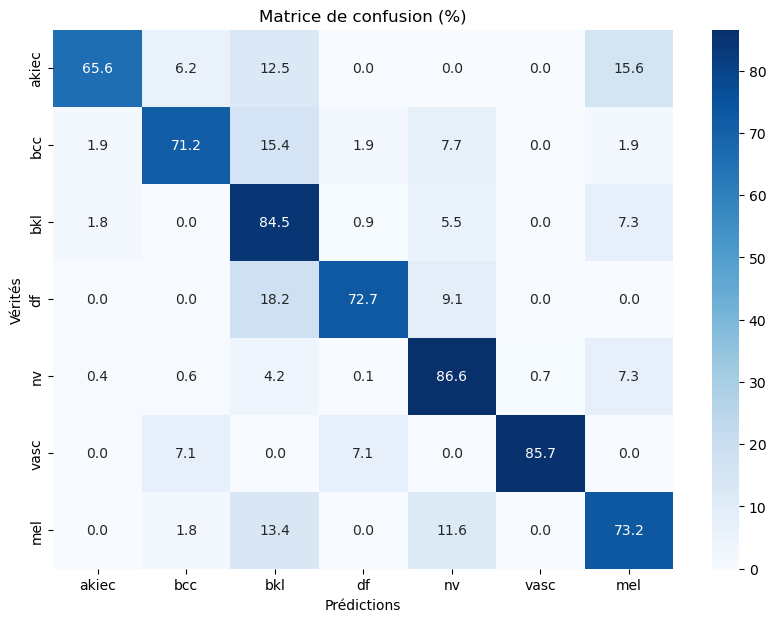

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = test_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()

/Users/eric/miniforge3/envs/tf-vit/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 204ms/step


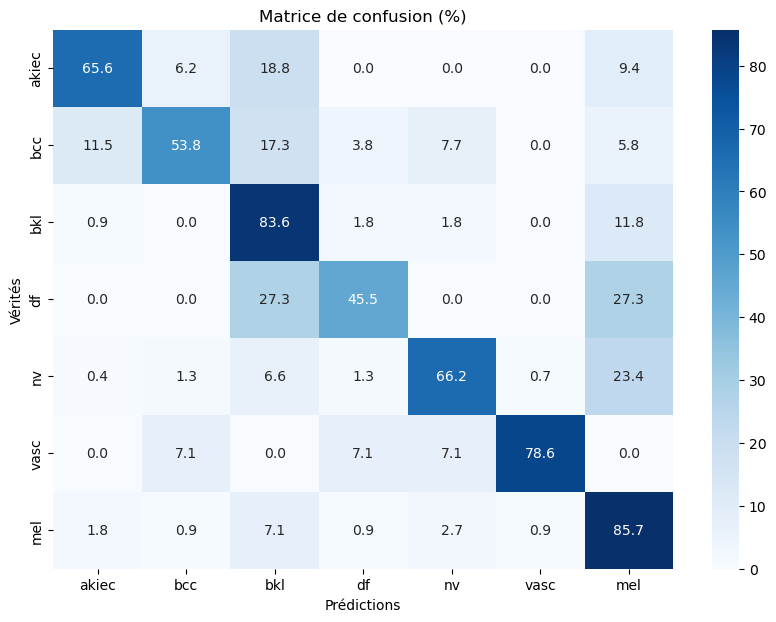

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = test_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = test_gen.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()


/Users/eric/miniforge3/envs/tf-vit/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 515ms/step


AttributeError: 'TargetedAugmentGenerator' object has no attribute 'classes'

/Users/eric/miniforge3/envs/tf-vit/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 191ms/step


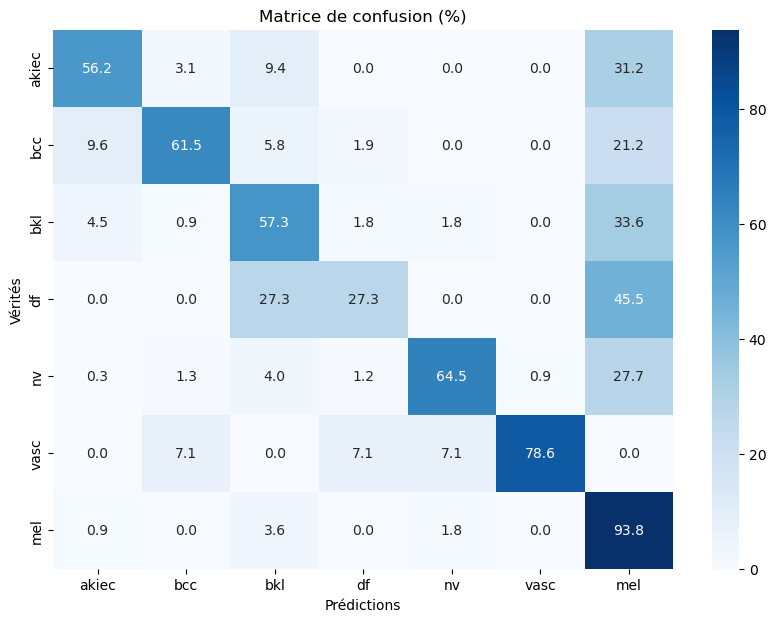

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = test_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()

/Users/eric/miniforge3/envs/tf-vit/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 193ms/step


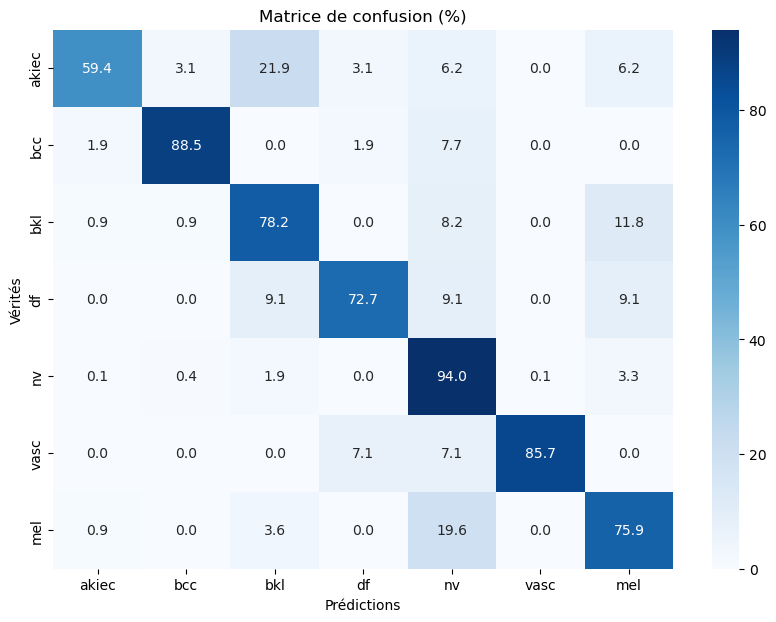

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = test_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 200ms/step


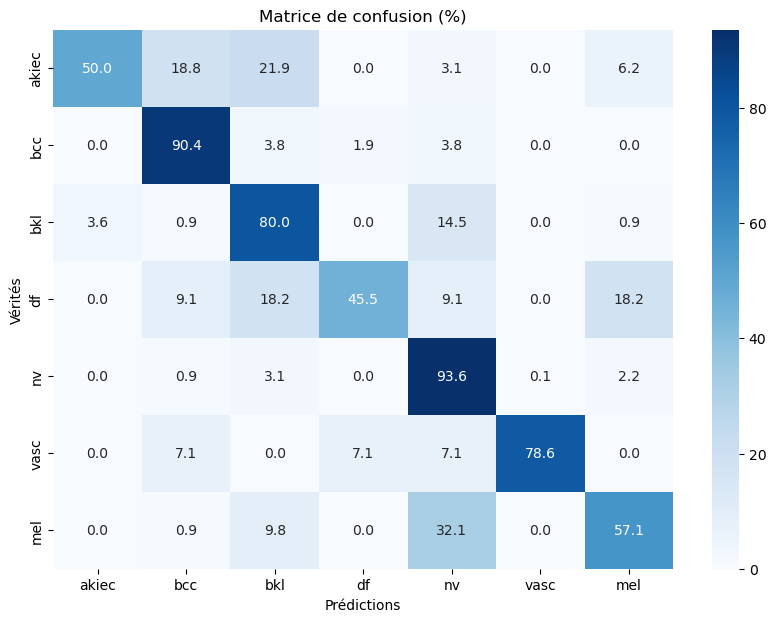

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = test_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()

/Users/eric/miniforge3/envs/tf-vit/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 178ms/step


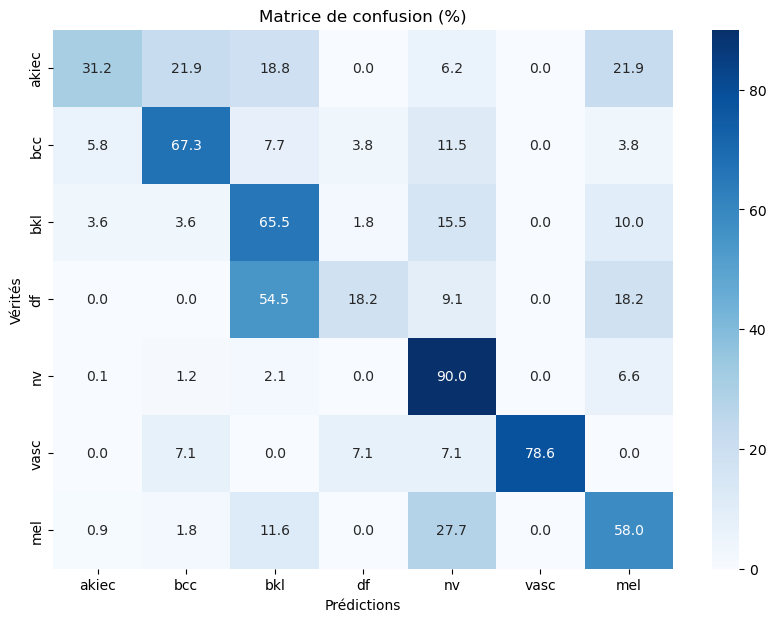

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = test_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()

/Users/eric/miniforge3/envs/tf-vit/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 180ms/step


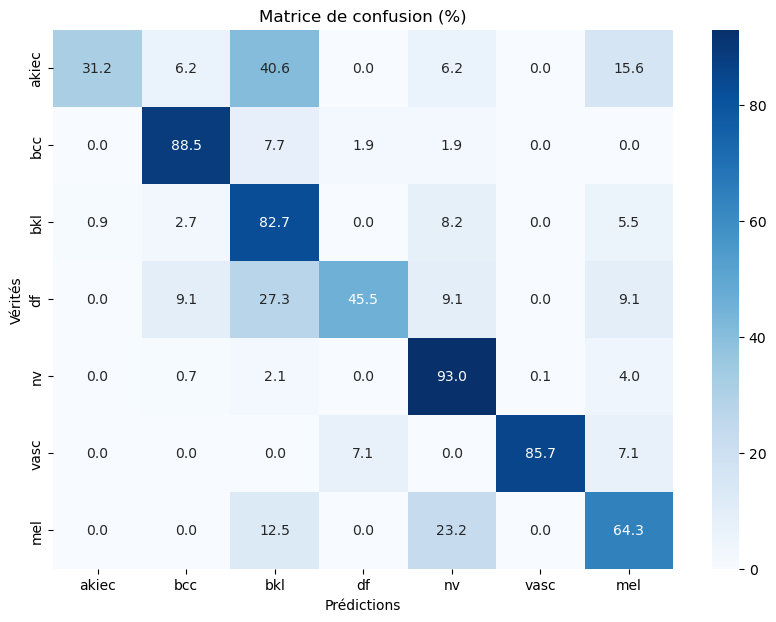

In [91]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = test_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()

/Users/eric/miniforge3/envs/tf-vit/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 192ms/step


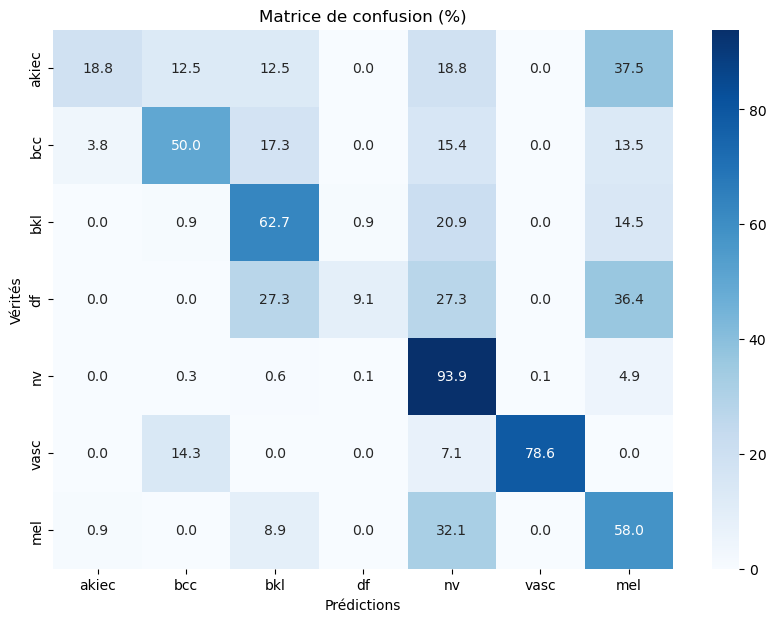

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = test_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()

/Users/eric/miniforge3/envs/tf-vit/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 28s 503ms/step


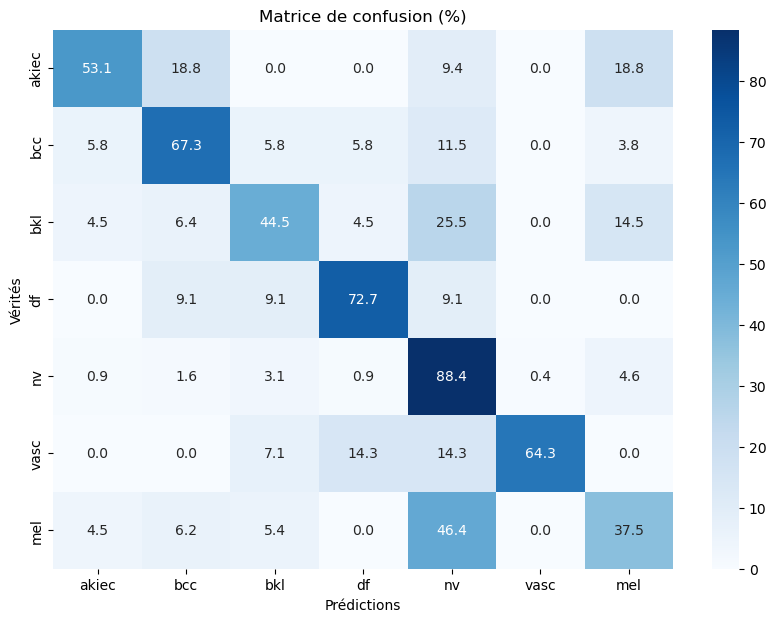

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = test_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = test_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()


NameError: name 'test_generator' is not defined

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = test_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()


NameError: name 'test_generator' is not defined

32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 183ms/step


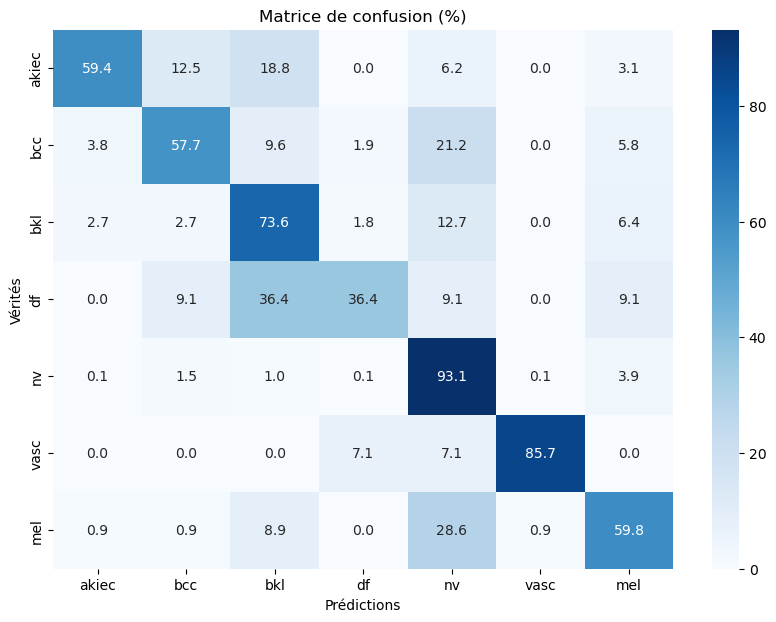

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = test_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()


32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 203ms/step


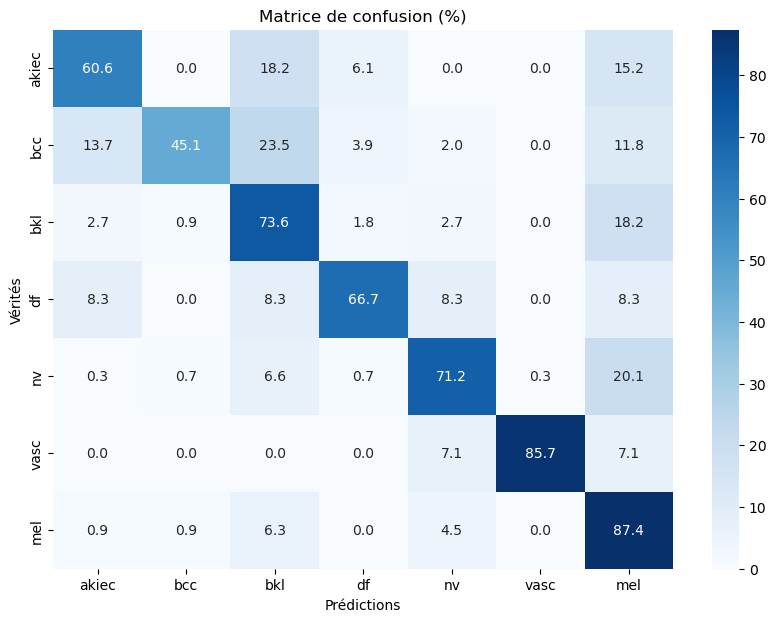

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = val_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()


32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 279ms/step


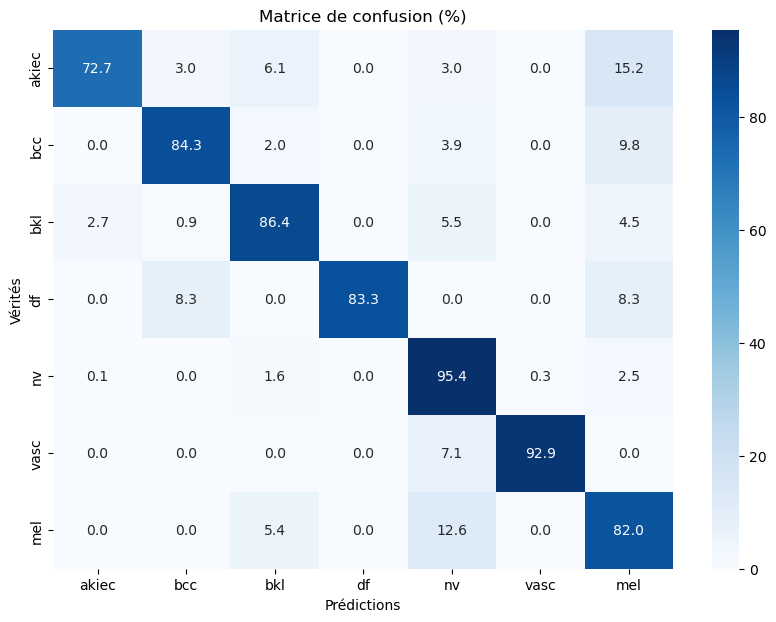

In [159]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = val_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()




In [21]:
from tensorflow.keras.utils import register_keras_serializable
from tensorflow.keras.layers import Layer
from tensorflow.keras import backend as K

@register_keras_serializable()
class SimpleAttention(Layer):
    def __init__(self, **kwargs):
        super(SimpleAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.attention_weights = self.add_weight(
            name='attention_weights',
            shape=(input_shape[-1], 1),
            initializer='random_normal',
            trainable=True,
        )
        super(SimpleAttention, self).build(input_shape)

    def call(self, inputs):
        score = K.dot(inputs, self.attention_weights)
        weights = K.softmax(score, axis=1)
        context = weights * inputs
        return K.sum(context, axis=1)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])


In [25]:
model_loaded = load_model("Xception-Attention.keras", compile=False, custom_objects={"SimpleAttention": SimpleAttention})
# Trouvez le nom de votre couche base_model (Xception) dans model_loaded.summary()
# Supposons que son nom soit 'xception'
xception_layer_loaded = model_loaded.get_layer('xception') # Remplacez 'xception' par le vrai nom
print("Output shape of loaded Xception:", xception_layer_loaded.output_shape)

ValueError: Input 0 of layer "global_average_pooling2d" is incompatible with the layer: expected ndim=4, found ndim=3. Full shape received: (None, 10, 2048)

32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 143ms/step


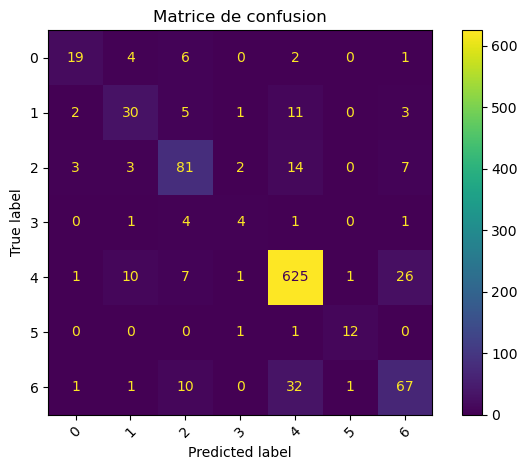

Rapport de classification :
              precision    recall  f1-score   support

           0       0.73      0.59      0.66        32
           1       0.61      0.58      0.59        52
           2       0.72      0.74      0.73       110
           3       0.44      0.36      0.40        11
           4       0.91      0.93      0.92       671
           5       0.86      0.86      0.86        14
           6       0.64      0.60      0.62       112

    accuracy                           0.84      1002
   macro avg       0.70      0.67      0.68      1002
weighted avg       0.83      0.84      0.83      1002



In [35]:
import json
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
#from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 📐 Taille d'image attendue par le modèle
IMG_SIZE = (224, 224)

# 1. Charger le DataFrame (à adapter selon ton cas réel)
# df = pd.read_csv("chemin/vers/ton_fichier.csv")  # Exemple

# 2. Charger les indices du jeu de test
##with open('split_indices.json', 'r') as f:
 #   split_indices = json.load(f)

#test_indices = split_indices['test']

# 3. Extraire les données de test
#test_df = df.loc[test_indices].copy()  # .copy() pour éviter SettingWithCopyWarning
test_df['label'] = test_df['label'].astype(str)

# 4. Charger le modèle
model = load_model('Protocole-S-Resnet50-akiec_bkl_mel_classweight1-valAUC.keras', compile=False)

# 5. Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

# Fonction pour appliquer à toutes les images
def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 6. Préparer les données
X_test = preprocess_images(test_df['path'])
y_true = test_df['label'].values

# 7. Prédictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Encodage des labels texte → entiers
class_indices = sorted(test_df['label'].unique())
label_to_index = {label: i for i, label in enumerate(class_indices)}
index_to_label = {i: label for label, i in label_to_index.items()}
y_true_encoded = np.array([label_to_index[label] for label in y_true])

# 8. Matrice de confusion
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_indices)
disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

# 9. Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=class_indices))


2025-07-02 20:38:19.701375: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-07-02 20:38:19.701426: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2025-07-02 20:38:19.701430: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
I0000 00:00:1751481499.701682   10851 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1751481499.701916   10851 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2025-07-02 20:38:25.779030: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 141ms/step


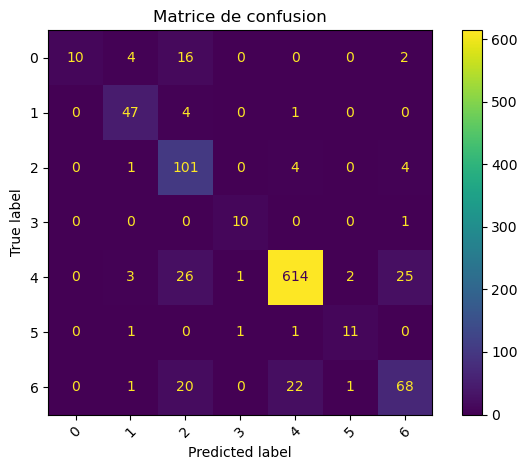

Rapport de classification :
              precision    recall  f1-score   support

           0       1.00      0.31      0.48        32
           1       0.82      0.90      0.86        52
           2       0.60      0.92      0.73       110
           3       0.83      0.91      0.87        11
           4       0.96      0.92      0.94       671
           5       0.79      0.79      0.79        14
           6       0.68      0.61      0.64       112

    accuracy                           0.86      1002
   macro avg       0.81      0.76      0.76      1002
weighted avg       0.88      0.86      0.86      1002



In [6]:
import json
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
#from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 📐 Taille d'image attendue par le modèle
IMG_SIZE = (224, 224)

# 1. Charger le DataFrame (à adapter selon ton cas réel)
# df = pd.read_csv("chemin/vers/ton_fichier.csv")  # Exemple

# 2. Charger les indices du jeu de test
##with open('split_indices.json', 'r') as f:
 #   split_indices = json.load(f)

#test_indices = split_indices['test']

# 3. Extraire les données de test
#test_df = df.loc[test_indices].copy()  # .copy() pour éviter SettingWithCopyWarning
test_df['label'] = test_df['label'].astype(str)

# 4. Charger le modèle
model = load_model('Protocole-S-Resnet50-V9phase6-valACC.keras', compile=False)

# 5. Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

# Fonction pour appliquer à toutes les images
def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 6. Préparer les données
X_test = preprocess_images(test_df['path'])
y_true = test_df['label'].values

# 7. Prédictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Encodage des labels texte → entiers
class_indices = sorted(test_df['label'].unique())
label_to_index = {label: i for i, label in enumerate(class_indices)}
index_to_label = {i: label for label, i in label_to_index.items()}
y_true_encoded = np.array([label_to_index[label] for label in y_true])

# 8. Matrice de confusion
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_indices)
disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

# 9. Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=class_indices))


2025-07-02 07:37:44.976452: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-07-02 07:37:44.976501: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2025-07-02 07:37:44.976505: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
I0000 00:00:1751434664.976772    9934 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1751434664.977018    9934 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2025-07-02 07:37:50.998628: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 137ms/step


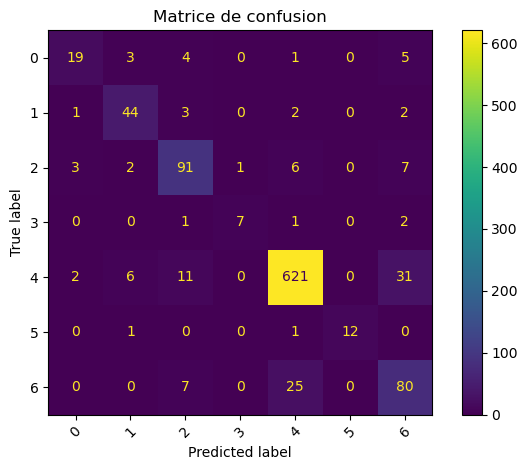

Rapport de classification :
              precision    recall  f1-score   support

           0       0.76      0.59      0.67        32
           1       0.79      0.85      0.81        52
           2       0.78      0.83      0.80       110
           3       0.88      0.64      0.74        11
           4       0.95      0.93      0.94       671
           5       1.00      0.86      0.92        14
           6       0.63      0.71      0.67       112

    accuracy                           0.87      1002
   macro avg       0.82      0.77      0.79      1002
weighted avg       0.88      0.87      0.87      1002



In [8]:
import json
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
#from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 📐 Taille d'image attendue par le modèle
IMG_SIZE = (224, 224)

# 1. Charger le DataFrame (à adapter selon ton cas réel)
# df = pd.read_csv("chemin/vers/ton_fichier.csv")  # Exemple

# 2. Charger les indices du jeu de test
##with open('split_indices.json', 'r') as f:
 #   split_indices = json.load(f)

#test_indices = split_indices['test']

# 3. Extraire les données de test
#test_df = df.loc[test_indices].copy()  # .copy() pour éviter SettingWithCopyWarning
test_df['label'] = test_df['label'].astype(str)

# 4. Charger le modèle
model = load_model('Protocole-S-Resnet50-V9phase3-valACC.keras', compile=False)

# 5. Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

# Fonction pour appliquer à toutes les images
def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 6. Préparer les données
X_test = preprocess_images(test_df['path'])
y_true = test_df['label'].values

# 7. Prédictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Encodage des labels texte → entiers
class_indices = sorted(test_df['label'].unique())
label_to_index = {label: i for i, label in enumerate(class_indices)}
index_to_label = {i: label for label, i in label_to_index.items()}
y_true_encoded = np.array([label_to_index[label] for label in y_true])

# 8. Matrice de confusion
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_indices)
disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

# 9. Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=class_indices))


32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 205ms/step


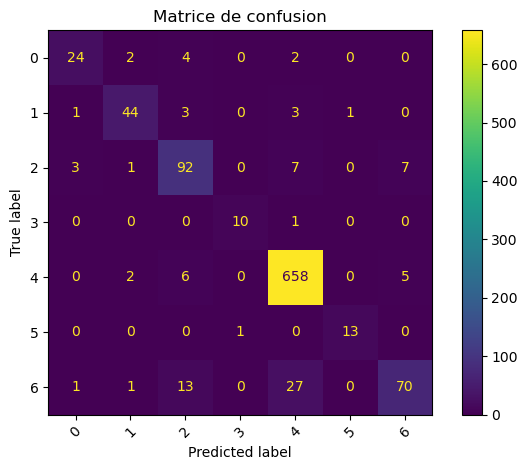

Rapport de classification :
              precision    recall  f1-score   support

           0       0.83      0.75      0.79        32
           1       0.88      0.85      0.86        52
           2       0.78      0.84      0.81       110
           3       0.91      0.91      0.91        11
           4       0.94      0.98      0.96       671
           5       0.93      0.93      0.93        14
           6       0.85      0.62      0.72       112

    accuracy                           0.91      1002
   macro avg       0.87      0.84      0.85      1002
weighted avg       0.91      0.91      0.91      1002



In [7]:
import json
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 📐 Taille d'image attendue par le modèle
IMG_SIZE = (299, 299)

# 1. Charger le DataFrame (à adapter selon ton cas réel)
# df = pd.read_csv("chemin/vers/ton_fichier.csv")  # Exemple

# 2. Charger les indices du jeu de test
##with open('split_indices.json', 'r') as f:
 #   split_indices = json.load(f)

#test_indices = split_indices['test']

# 3. Extraire les données de test
#test_df = df.loc[test_indices].copy()  # .copy() pour éviter SettingWithCopyWarning
test_df['label'] = test_df['label'].astype(str)

# 4. Charger le modèle
model = load_model('Protocole-S-V2-InceptionV3-phase13-valACC.keras', compile=False)

# 5. Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

# Fonction pour appliquer à toutes les images
def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 6. Préparer les données
X_test = preprocess_images(test_df['path'])
y_true = test_df['label'].values

# 7. Prédictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Encodage des labels texte → entiers
class_indices = sorted(test_df['label'].unique())
label_to_index = {label: i for i, label in enumerate(class_indices)}
index_to_label = {i: label for label, i in label_to_index.items()}
y_true_encoded = np.array([label_to_index[label] for label in y_true])

# 8. Matrice de confusion
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_indices)
disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

# 9. Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=class_indices))


32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 198ms/step


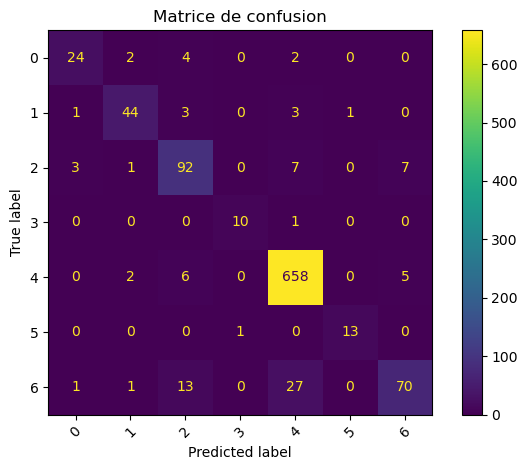

Rapport de classification :
              precision    recall  f1-score   support

           0       0.83      0.75      0.79        32
           1       0.88      0.85      0.86        52
           2       0.78      0.84      0.81       110
           3       0.91      0.91      0.91        11
           4       0.94      0.98      0.96       671
           5       0.93      0.93      0.93        14
           6       0.85      0.62      0.72       112

    accuracy                           0.91      1002
   macro avg       0.87      0.84      0.85      1002
weighted avg       0.91      0.91      0.91      1002



In [6]:
import json
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 📐 Taille d'image attendue par le modèle
IMG_SIZE = (299, 299)

# 1. Charger le DataFrame (à adapter selon ton cas réel)
# df = pd.read_csv("chemin/vers/ton_fichier.csv")  # Exemple

# 2. Charger les indices du jeu de test
##with open('split_indices.json', 'r') as f:
 #   split_indices = json.load(f)

#test_indices = split_indices['test']

# 3. Extraire les données de test
#test_df = df.loc[test_indices].copy()  # .copy() pour éviter SettingWithCopyWarning
test_df['label'] = test_df['label'].astype(str)

# 4. Charger le modèle
model = load_model('Protocole-S-V2-InceptionV3-phase13-valACC.keras', compile=False)

# 5. Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

# Fonction pour appliquer à toutes les images
def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 6. Préparer les données
X_test = preprocess_images(test_df['path'])
y_true = test_df['label'].values

# 7. Prédictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Encodage des labels texte → entiers
class_indices = sorted(test_df['label'].unique())
label_to_index = {label: i for i, label in enumerate(class_indices)}
index_to_label = {i: label for label, i in label_to_index.items()}
y_true_encoded = np.array([label_to_index[label] for label in y_true])

# 8. Matrice de confusion
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_indices)
disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

# 9. Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=class_indices))


2025-06-21 10:26:56.930182: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-06-21 10:26:56.930220: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2025-06-21 10:26:56.930224: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
I0000 00:00:1750494416.930245  146077 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1750494416.930275  146077 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2025-06-21 10:27:03.085812: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 262ms/step


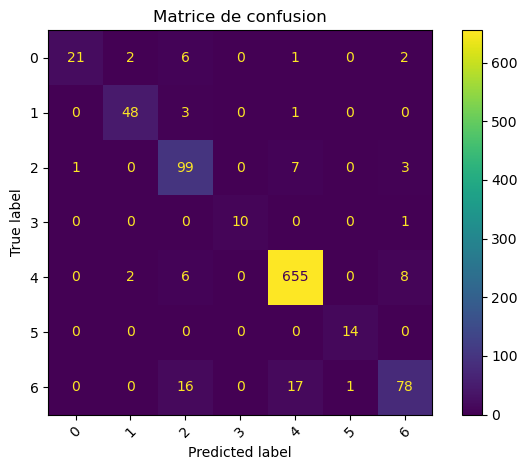

Rapport de classification :
              precision    recall  f1-score   support

           0       0.95      0.66      0.78        32
           1       0.92      0.92      0.92        52
           2       0.76      0.90      0.82       110
           3       1.00      0.91      0.95        11
           4       0.96      0.98      0.97       671
           5       0.93      1.00      0.97        14
           6       0.85      0.70      0.76       112

    accuracy                           0.92      1002
   macro avg       0.91      0.87      0.88      1002
weighted avg       0.92      0.92      0.92      1002



In [10]:
import json
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.xception import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 📐 Taille d'image attendue par le modèle
IMG_SIZE = (299, 299)

# 1. Charger le DataFrame (à adapter selon ton cas réel)
# df = pd.read_csv("chemin/vers/ton_fichier.csv")  # Exemple

# 2. Charger les indices du jeu de test
##with open('split_indices.json', 'r') as f:
 #   split_indices = json.load(f)

#test_indices = split_indices['test']

# 3. Extraire les données de test
#test_df = df.loc[test_indices].copy()  # .copy() pour éviter SettingWithCopyWarning
test_df['label'] = test_df['label'].astype(str)

# 4. Charger le modèle
model = load_model('Protocole-S-V2-Xception-phase9-valACC.keras', compile=False)

# 5. Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

# Fonction pour appliquer à toutes les images
def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 6. Préparer les données
X_test = preprocess_images(test_df['path'])
y_true = test_df['label'].values

# 7. Prédictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Encodage des labels texte → entiers
class_indices = sorted(test_df['label'].unique())
label_to_index = {label: i for i, label in enumerate(class_indices)}
index_to_label = {i: label for label, i in label_to_index.items()}
y_true_encoded = np.array([label_to_index[label] for label in y_true])

# 8. Matrice de confusion
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_indices)
disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

# 9. Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=class_indices))


32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 304ms/step


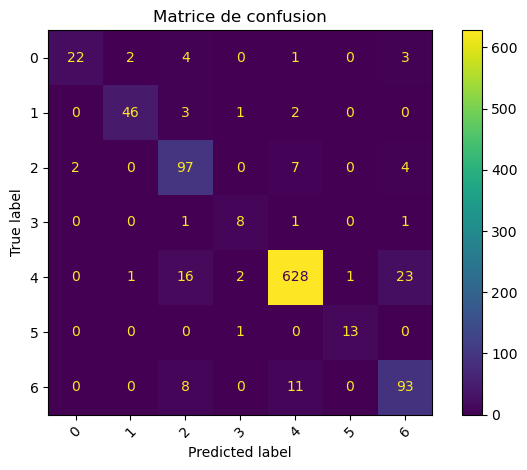

Rapport de classification :
              precision    recall  f1-score   support

           0       0.92      0.69      0.79        32
           1       0.94      0.88      0.91        52
           2       0.75      0.88      0.81       110
           3       0.67      0.73      0.70        11
           4       0.97      0.94      0.95       671
           5       0.93      0.93      0.93        14
           6       0.75      0.83      0.79       112

    accuracy                           0.91      1002
   macro avg       0.85      0.84      0.84      1002
weighted avg       0.91      0.91      0.91      1002



In [75]:
import json
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.xception import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 📐 Taille d'image attendue par le modèle
IMG_SIZE = (299, 299)

# 1. Charger le DataFrame (à adapter selon ton cas réel)
# df = pd.read_csv("chemin/vers/ton_fichier.csv")  # Exemple

# 2. Charger les indices du jeu de test
##with open('split_indices.json', 'r') as f:
 #   split_indices = json.load(f)

#test_indices = split_indices['test']

# 3. Extraire les données de test
#test_df = df.loc[test_indices].copy()  # .copy() pour éviter SettingWithCopyWarning
test_df['label'] = test_df['label'].astype(str)

# 4. Charger le modèle
model = load_model('SBXception-Basic-LowReg_best_accuracy.keras', compile=False)

# 5. Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

# Fonction pour appliquer à toutes les images
def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 6. Préparer les données
X_test = preprocess_images(test_df['path'])
y_true = test_df['label'].values

# 7. Prédictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Encodage des labels texte → entiers
class_indices = sorted(test_df['label'].unique())
label_to_index = {label: i for i, label in enumerate(class_indices)}
index_to_label = {i: label for label, i in label_to_index.items()}
y_true_encoded = np.array([label_to_index[label] for label in y_true])

# 8. Matrice de confusion
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_indices)
disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

# 9. Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=class_indices))


32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 263ms/step


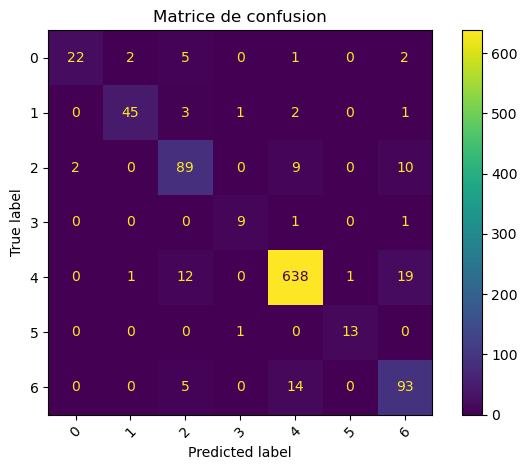

Rapport de classification :
              precision    recall  f1-score   support

           0       0.92      0.69      0.79        32
           1       0.94      0.87      0.90        52
           2       0.78      0.81      0.79       110
           3       0.82      0.82      0.82        11
           4       0.96      0.95      0.96       671
           5       0.93      0.93      0.93        14
           6       0.74      0.83      0.78       112

    accuracy                           0.91      1002
   macro avg       0.87      0.84      0.85      1002
weighted avg       0.91      0.91      0.91      1002



In [16]:
import json
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.xception import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 📐 Taille d'image attendue par le modèle
IMG_SIZE = (299, 299)

# 1. Charger le DataFrame (à adapter selon ton cas réel)
# df = pd.read_csv("chemin/vers/ton_fichier.csv")  # Exemple

# 2. Charger les indices du jeu de test
##with open('split_indices.json', 'r') as f:
 #   split_indices = json.load(f)

#test_indices = split_indices['test']

# 3. Extraire les données de test
#test_df = df.loc[test_indices].copy()  # .copy() pour éviter SettingWithCopyWarning
test_df['label'] = test_df['label'].astype(str)

# 4. Charger le modèle
model = load_model('SBXception-Basic-LowReg_best_accuracy.keras', compile=False)

# 5. Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

# Fonction pour appliquer à toutes les images
def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 6. Préparer les données
X_test = preprocess_images(test_df['path'])
y_true = test_df['label'].values

# 7. Prédictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Encodage des labels texte → entiers
class_indices = sorted(test_df['label'].unique())
label_to_index = {label: i for i, label in enumerate(class_indices)}
index_to_label = {i: label for label, i in label_to_index.items()}
y_true_encoded = np.array([label_to_index[label] for label in y_true])

# 8. Matrice de confusion
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_indices)
disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

# 9. Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=class_indices))
